In [1]:
# ============================================================
# CELL 1: Imports, GAS CONFIG, cleanup, and master matrix builder
#
# Foundational cell for the whole notebook: imports, the gas-specific
# configuration block, and the raw-data loading functions used by
# every regression cell below. It also defines a handful of binary
# threshold/label constants (flagged inline below) that exist only to
# support the binary-classifier cells later in the notebook; they are
# harmless to leave here even if those classifier cells are removed.
# ============================================================

import os
import glob
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Reproducibility constants
# -----------------------------

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ============================================================
# >>> GAS CONFIGURATION  (THE ONLY PLACE YOU NEED TO EDIT) <<<
# ------------------------------------------------------------
# Set the gas once here. Every heading, plot title and label
# downstream updates automatically. Nothing else needs editing,
# and the methodology is unchanged.
# ============================================================

GAS_NAME = "Ammonia"          # <-- set your gas here (e.g. "Acetone", "Methanol")
DATA_ROOT = "../data/"        # folder with one subfolder per gas, named exactly GAS_NAME

# Fixed experimental concentration grid for this gas (ppm).
# Edit only if a different gas was measured on a different grid.
ALLOWED_CONCENTRATIONS = np.array(
    [2,4, 6,8, 10, 12,14,16,18,20, 25,30,35, 40],
    dtype=float
)

# Binary endpoint definition for this gas.
# (binary-classifier-only constant; see flag in CELL 1 above)
HIGH_THRESHOLD_PPM = 20.0     # concentrations >= this are the "High" class

EXPECTED_SPECTRA = 42        # total spectra expected (n_concentrations * n_replicates)
EXPECTED_FEATURES = 3648      # detector pixels per spectrum

# ------------------------------------------------------------
# Derived identifiers (do not edit) - everything below is generic.
# ------------------------------------------------------------
TARGETS = [GAS_NAME]

# --- BINARY CLASSIFIER CONFIG (used only by the flagged classifier cells below) ---
# Dynamic binary class labels derived from the grid + threshold.
_below = ALLOWED_CONCENTRATIONS[ALLOWED_CONCENTRATIONS < HIGH_THRESHOLD_PPM]
_atabove = ALLOWED_CONCENTRATIONS[ALLOWED_CONCENTRATIONS >= HIGH_THRESHOLD_PPM]
NEGATIVE_CLASS = f"Not_High_{int(_below.min())}_{int(_below.max())}"
POSITIVE_CLASS = f"High_{int(_atabove.min())}_{int(_atabove.max())}"
BINARY_LABELS = [NEGATIVE_CLASS, POSITIVE_CLASS]
# --- end binary classifier config ---

# Acquisition condition for this dataset.
REPLICATE_STATUS = (
    "same_day_same_vial_same_cuvette_same_loading_consecutive_technical_scans"
)

VALIDATION_INTERPRETATION = (
    "Replicate-held-out CV is only a same-sample repeat-scan diagnostic. "
    "The main stricter validation is leave-one-concentration-out CV."
)

# Binary endpoint is exploratory/post-hoc unless there is an independent
# reason for the chosen threshold.
# (binary-classifier-only constant)
BINARY_ENDPOINT_STATUS = "exploratory_post_hoc_unless_independently_justified"

# -----------------------------
# Data loading functions
# -----------------------------

def cleanup(filepath):
    """
    Clean one raw spectrum file.

    This function performs only mechanical cleanup:
    - drop header rows
    - split wavelength and intensity
    - convert to numeric
    - drop nonnumeric rows
    - sort wavelength axis

    It does not use ppm labels and does not learn from the dataset.
    """
    df = pd.read_csv(filepath, header=None)
    df = df.drop(df.index[:12])

    df[["Wavelength", "Intensity"]] = (
        df.iloc[:, 0].astype(str).str.split(n=1, expand=True)
    )

    df["Wavelength"] = pd.to_numeric(df["Wavelength"], errors="coerce")
    df["Intensity"] = pd.to_numeric(df["Intensity"], errors="coerce")

    df = df.dropna(subset=["Wavelength", "Intensity"])
    df = df.sort_values("Wavelength").reset_index(drop=True)

    return df[["Wavelength", "Intensity"]]


def extract_ppm_from_filename(filename):
    """Parse the ppm concentration out of a filename like 'acetone_20ppm_2.txt'."""
    match = re.search(r"(\d+\.?\d*)\s*ppm", filename.lower())
    if match is None:
        raise ValueError(f"Could not extract ppm from filename: {filename}")
    return float(match.group(1))


def extract_replicate_id(filename):
    """
    Expected filename examples:
    ethanol_0ppm_1.txt
    ethanol_20ppm_2.txt
    ethanol_100ppm_3.txt
    """
    match = re.search(r"_(\d+)\.txt$", filename.lower())
    if match is None:
        raise ValueError(f"Could not extract replicate ID from filename: {filename}")
    return int(match.group(1))


def build_master_matrix(data_root, target_gases):
    """
    Load every .txt spectrum for each gas folder under data_root and
    assemble them into one master dataframe (metadata + Pixel_<i> columns).
    Returns (final_df, wavelengths).
    """
    all_intensities = []
    metadata = []
    wavelengths = None

    for gas in target_gases:
        folder_path = os.path.join(data_root, gas)
        files = sorted(glob.glob(os.path.join(folder_path, "*.txt")))

        print(f"{gas}: found {len(files)} files")

        for f in files:
            filename = os.path.basename(f)

            df_temp = cleanup(f)
            current_wavelengths = df_temp["Wavelength"].values

            if wavelengths is None:
                wavelengths = current_wavelengths
            else:
                # Integrity check: every spectrum must share the same
                # pixel grid (both length and actual wavelength values),
                # otherwise a different instrument setting could be
                # silently mixed into the stacked matrix below.
                if len(current_wavelengths) != len(wavelengths):
                    raise ValueError(f"Wavelength length mismatch in file: {filename}")

                if not np.allclose(current_wavelengths, wavelengths):
                    raise ValueError(f"Wavelength grid mismatch in file: {filename}")

            ppm = extract_ppm_from_filename(filename)
            replicate = extract_replicate_id(filename)

            metadata.append({
                "Gas_Type": gas,
                "Concentration": ppm,
                "Replicate": replicate,
                "Filename": filename
            })

            all_intensities.append(df_temp["Intensity"].values)

    pixel_df = pd.DataFrame(all_intensities)
    pixel_df.columns = [f"Pixel_{i}" for i in range(pixel_df.shape[1])]

    meta_df = pd.DataFrame(metadata)
    final_df = pd.concat([meta_df, pixel_df], axis=1)

    return final_df, wavelengths


print("CELL 0 COMPLETE")
print("Gas:", GAS_NAME)
print("Replicate status:", REPLICATE_STATUS)
print("Validation interpretation:", VALIDATION_INTERPRETATION)
print("Expected ppm grid:", ALLOWED_CONCENTRATIONS)

CELL 0 COMPLETE
Gas: Ammonia
Replicate status: same_day_same_vial_same_cuvette_same_loading_consecutive_technical_scans
Validation interpretation: Replicate-held-out CV is only a same-sample repeat-scan diagnostic. The main stricter validation is leave-one-concentration-out CV.
Expected ppm grid: [ 2.  4.  6.  8. 10. 12. 14. 16. 18. 20. 25. 30. 35. 40.]


In [2]:
# ============================================================
# CELL 2: Build gas master matrix
#
# Calls build_master_matrix() (defined in CELL 1) to walk the data
# folder and assemble every spectrum for this gas into one wide
# dataframe (one row per spectrum, one column per detector pixel).
# ============================================================

df_master, wl_reference = build_master_matrix(DATA_ROOT, TARGETS)

print("\nMaster Matrix Created")
print("Shape:", df_master.shape)
print("\nFirst 5 rows:")
print(df_master.head())

Ammonia: found 42 files

Master Matrix Created
Shape: (42, 3652)

First 5 rows:
  Gas_Type  Concentration  Replicate             Filename  Pixel_0  Pixel_1  \
0  Ammonia           10.0          1  ammonia_10ppm_1.txt  -102.85  -102.85   
1  Ammonia           10.0          2  ammonia_10ppm_2.txt   -70.85   -70.85   
2  Ammonia           10.0          3  ammonia_10ppm_3.txt  -112.54  -112.54   
3  Ammonia           12.0          1  ammonia_12ppm_1.txt  -100.31  -100.31   
4  Ammonia           12.0          2  ammonia_12ppm_2.txt   -82.08   -82.08   

   Pixel_2  Pixel_3  Pixel_4  Pixel_5  ...  Pixel_3638  Pixel_3639  \
0  -102.85  -101.85   -27.85    -0.85  ...       15.15       -1.85   
1   -70.85  -107.85   -18.85    23.15  ...        0.15        7.15   
2  -112.54   -89.54    -4.54     8.46  ...        8.46       -9.54   
3  -100.31   -96.31   -29.31     1.69  ...       10.69        9.69   
4   -82.08  -113.08   -15.08   -16.08  ...        4.92      -11.08   

   Pixel_3640  Pixel_364

In [3]:
# ============================================================
# CELL 3: Strict data integrity checks
#
# Hard assertions that the loaded dataset matches what the rest of the
# notebook assumes: expected spectra count, expected pixel count, the
# exact concentration grid, and no missing values. Failing fast here
# avoids silently running the regression pipeline on malformed data.
# ============================================================

pixel_cols = [c for c in df_master.columns if c.startswith("Pixel_")]
pixel_cols = sorted(pixel_cols, key=lambda x: int(x.split("_")[1]))

found_ppms = np.sort(df_master["Concentration"].unique())

print("Master dataframe shape:", df_master.shape)
print("Number of pixel columns:", len(pixel_cols))
print("Wavelength reference length:", len(wl_reference))

print("\nGas counts:")
print(df_master["Gas_Type"].value_counts())

print("\nConcentration counts:")
print(df_master["Concentration"].value_counts().sort_index())

print("\nReplicate counts:")
print(df_master["Replicate"].value_counts().sort_index())

print("\nFound ppm grid:")
print(found_ppms)

print("\nExpected ppm grid:")
print(ALLOWED_CONCENTRATIONS)

print("\nDoes found ppm grid match expected grid?")
print(np.array_equal(found_ppms, ALLOWED_CONCENTRATIONS))

print("\nMissing metadata values:")
print(df_master[["Gas_Type", "Concentration", "Replicate", "Filename"]].isna().sum())

print("\nMissing spectral values:")
print(df_master[pixel_cols].isna().sum().sum())

assert df_master.shape[0] == EXPECTED_SPECTRA, "Unexpected number of spectra"
assert len(pixel_cols) == EXPECTED_FEATURES, "Unexpected number of spectral features"
assert len(wl_reference) == EXPECTED_FEATURES, "Unexpected wavelength length"
assert np.array_equal(found_ppms, ALLOWED_CONCENTRATIONS), "Unexpected ppm grid"
assert df_master[pixel_cols].isna().sum().sum() == 0, "Missing spectral values found"

print("\nCELL 2 PASSED: data integrity checks passed.")

Master dataframe shape: (42, 3652)
Number of pixel columns: 3648
Wavelength reference length: 3648

Gas counts:
Gas_Type
Ammonia    42
Name: count, dtype: int64

Concentration counts:
Concentration
2.0     3
4.0     3
6.0     3
8.0     3
10.0    3
12.0    3
14.0    3
16.0    3
18.0    3
20.0    3
25.0    3
30.0    3
35.0    3
40.0    3
Name: count, dtype: int64

Replicate counts:
Replicate
1    14
2    14
3    14
Name: count, dtype: int64

Found ppm grid:
[ 2.  4.  6.  8. 10. 12. 14. 16. 18. 20. 25. 30. 35. 40.]

Expected ppm grid:
[ 2.  4.  6.  8. 10. 12. 14. 16. 18. 20. 25. 30. 35. 40.]

Does found ppm grid match expected grid?
True

Missing metadata values:
Gas_Type         0
Concentration    0
Replicate        0
Filename         0
dtype: int64

Missing spectral values:
0

CELL 2 PASSED: data integrity checks passed.


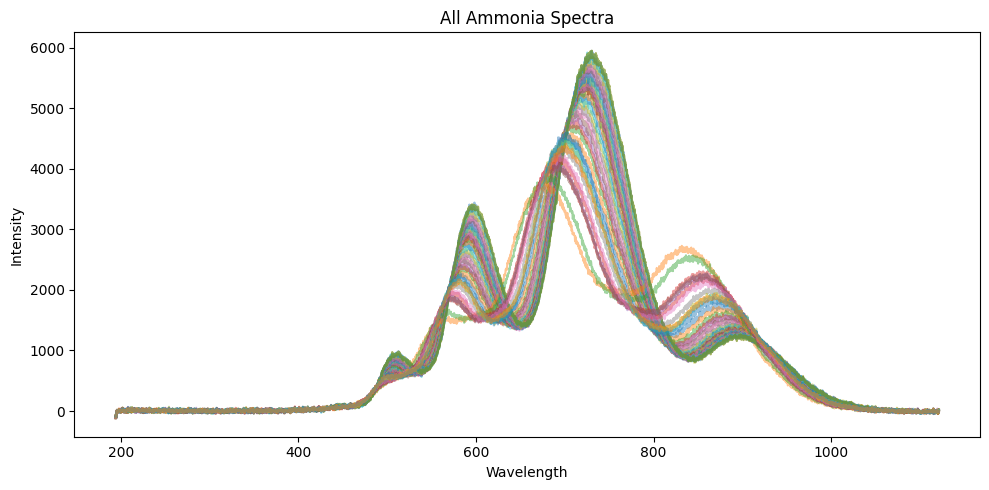

In [4]:
# ============================================================
# CELL 4: Visual spectrum check
#
# Quick eyeball check: overlay every loaded spectrum to confirm the
# data looks like sensible NIR spectra (no obvious truncation, scaling,
# or parsing artifacts) before any modeling begins.
# ============================================================

plt.figure(figsize=(10, 5))

for idx, row in df_master.iterrows():
    y_vals = row[pixel_cols].values.astype(float)
    ppm = row["Concentration"]
    plt.plot(wl_reference, y_vals, alpha=0.45)

plt.xlabel("Wavelength")
plt.ylabel("Intensity")
plt.title(f"All {GAS_NAME} Spectra")
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# CELL 5: Create X/y and fixed class helper
#
# Builds the feature matrix X (pixel intensities) and regression target
# y (ppm). nearest_concentration() is a "class" only in the sense of
# snapping a continuous regression prediction to the nearest value on
# the discrete experimental ppm grid (e.g. 47.8 -> 50) for an easy
# nearest-grid-point accuracy metric; it is not related to the binary
# classifier cells flagged later in this notebook.
# ============================================================

X = df_master[pixel_cols].values.astype(float)
y = df_master["Concentration"].values.astype(float)

allowed_concentrations = ALLOWED_CONCENTRATIONS.copy()

def nearest_concentration(pred, allowed=ALLOWED_CONCENTRATIONS):
    """Snap a continuous prediction to the closest value on the experimental ppm grid."""
    return allowed[np.argmin(np.abs(allowed - pred))]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Allowed concentrations:", allowed_concentrations)

assert X.shape == (EXPECTED_SPECTRA, EXPECTED_FEATURES)
assert y.shape == (EXPECTED_SPECTRA,)

print("\nCELL 4 PASSED: X/y created using fixed ppm grid.")

X shape: (42, 3648)
y shape: (42,)
Allowed concentrations: [ 2.  4.  6.  8. 10. 12. 14. 16. 18. 20. 25. 30. 35. 40.]

CELL 4 PASSED: X/y created using fixed ppm grid.


In [6]:
# ============================================================
# CELL 6: Validation split definitions and leakage audit
#
# Defines the two cross-validation grouping schemes used throughout
# the notebook: a same-session repeat-scan split (diagnostic only) and
# the leave-one-concentration-out (LOGO) split that is the paper's main
# leakage-safe validation unit. Every LOGO fold is asserted to have
# zero concentration overlap between train and test.
# ============================================================

# ------------------------------------------------------------
# A. Technical repeat-scan CV
# ------------------------------------------------------------
# This is NOT independent sample validation because you confirmed
# the three replicates were same-day, same-vial/cuvette/loading
# consecutive scans.
#
# Use this only as a repeatability diagnostic.
# ------------------------------------------------------------

repeat_scan_splits = []

for test_rep in sorted(df_master["Replicate"].unique()):
    test_idx = df_master.index[df_master["Replicate"] == test_rep].to_numpy()
    train_idx = df_master.index[df_master["Replicate"] != test_rep].to_numpy()
    repeat_scan_splits.append((train_idx, test_idx))

print("Technical repeat-scan CV:")
for fold_number, (train_idx, test_idx) in enumerate(repeat_scan_splits, start=1):
    print(f"\nRepeat-scan fold {fold_number}")
    print("Test replicate:", df_master.loc[test_idx, "Replicate"].unique())
    print("Train size:", len(train_idx))
    print("Test size:", len(test_idx))
    print("Test concentration count:", df_master.loc[test_idx, "Concentration"].nunique())

# ------------------------------------------------------------
# B. Main stricter validation: Leave-One-Concentration-Out CV
# ------------------------------------------------------------
# This directly addresses the leakage concern:
# if 20 ppm is the test fold, ALL 20 ppm spectra are removed
# from training.
# ------------------------------------------------------------

logo_concentration_splits = []

for test_ppm in ALLOWED_CONCENTRATIONS:
    test_idx = df_master.index[df_master["Concentration"] == test_ppm].to_numpy()
    train_idx = df_master.index[df_master["Concentration"] != test_ppm].to_numpy()
    logo_concentration_splits.append((train_idx, test_idx))

print("\n\nMain validation: Leave-One-Concentration-Out CV")
for fold_number, (train_idx, test_idx) in enumerate(logo_concentration_splits, start=1):
    test_ppms = np.sort(df_master.loc[test_idx, "Concentration"].unique())
    train_ppms = np.sort(df_master.loc[train_idx, "Concentration"].unique())
    overlap = set(test_ppms) & set(train_ppms)

    print(f"\nLOGO concentration fold {fold_number}")
    print("Held-out concentration:", test_ppms)
    print("Train size:", len(train_idx))
    print("Test size:", len(test_idx))
    print("Overlap between train/test concentrations:", overlap)

    assert len(test_ppms) == 1
    assert len(test_idx) == 3
    assert len(overlap) == 0, "Leakage: test concentration appears in training data"

print("\nCELL 5 PASSED:")
print("- Repeat-scan CV created for diagnostic only.")
print("- Leave-one-concentration-out CV created as main stricter validation.")
print("- Zero concentration overlap confirmed in every LOGO fold.")

Technical repeat-scan CV:

Repeat-scan fold 1
Test replicate: [1]
Train size: 28
Test size: 14
Test concentration count: 14

Repeat-scan fold 2
Test replicate: [2]
Train size: 28
Test size: 14
Test concentration count: 14

Repeat-scan fold 3
Test replicate: [3]
Train size: 28
Test size: 14
Test concentration count: 14


Main validation: Leave-One-Concentration-Out CV

LOGO concentration fold 1
Held-out concentration: [2.]
Train size: 39
Test size: 3
Overlap between train/test concentrations: set()

LOGO concentration fold 2
Held-out concentration: [4.]
Train size: 39
Test size: 3
Overlap between train/test concentrations: set()

LOGO concentration fold 3
Held-out concentration: [6.]
Train size: 39
Test size: 3
Overlap between train/test concentrations: set()

LOGO concentration fold 4
Held-out concentration: [8.]
Train size: 39
Test size: 3
Overlap between train/test concentrations: set()

LOGO concentration fold 5
Held-out concentration: [10.]
Train size: 39
Test size: 3
Overlap betwe

In [7]:
# ============================================================
# CELL 7: Preprocessing transformers
#
# Custom sklearn-compatible transformers (Savitzky-Golay, SNV) used
# inside every Pipeline in this notebook. Both operate row-wise per
# spectrum with no cross-sample statistics, so they are safe to place
# inside a CV pipeline without causing leakage.
# ============================================================

from sklearn.base import BaseEstimator, TransformerMixin
from scipy.signal import savgol_filter

class SavitzkyGolayTransformer(BaseEstimator, TransformerMixin):
    """
    Applies Savitzky-Golay smoothing or derivative along each spectrum.

    This transformer does not learn population-level statistics.
    It is safe inside CV pipelines.
    """
    def __init__(self, window_length=11, polyorder=2, deriv=0):
        self.window_length = window_length
        self.polyorder = polyorder
        self.deriv = deriv

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if self.window_length >= X.shape[1]:
            raise ValueError("window_length must be smaller than number of features")
        if self.window_length % 2 == 0:
            raise ValueError("window_length must be odd")
        return savgol_filter(
            X,
            window_length=self.window_length,
            polyorder=self.polyorder,
            deriv=self.deriv,
            axis=1
        )

class SNVTransformer(BaseEstimator, TransformerMixin):
    """
    Standard Normal Variate normalization.

    Each spectrum is normalized using only its own mean and std.
    It does not use labels and does not learn from other samples.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        mean = np.mean(X, axis=1, keepdims=True)
        std = np.std(X, axis=1, keepdims=True)
        std[std == 0] = 1.0
        return (X - mean) / std

print("CELL 6 COMPLETE: preprocessing transformers defined.")

CELL 6 COMPLETE: preprocessing transformers defined.


In [8]:
# ============================================================
# CELL 8: Preprocessing sanity check only
#
# Runs the transformers from CELL 7 once on the full dataset purely to
# confirm shapes are preserved and SNV actually produces mean ~0 /
# std ~1 per spectrum. No model is fit here.
# ============================================================

sg = SavitzkyGolayTransformer(window_length=11, polyorder=2, deriv=0)
snv = SNVTransformer()

X_sg = sg.fit_transform(X)
X_snv = snv.fit_transform(X_sg)

print("Original X shape:", X.shape)
print("After Savitzky-Golay shape:", X_sg.shape)
print("After SNV shape:", X_snv.shape)

print("\nOriginal first spectrum mean/std:")
print(np.mean(X[0]), np.std(X[0]))

print("\nAfter SNV first spectrum mean/std:")
print(np.mean(X_snv[0]), np.std(X_snv[0]))

assert X_sg.shape == X.shape
assert X_snv.shape == X.shape
assert np.isclose(np.mean(X_snv[0]), 0.0, atol=1e-10)
assert np.isclose(np.std(X_snv[0]), 1.0, atol=1e-10)

print("\nCELL 7 PASSED: preprocessing sanity check passed.")

Original X shape: (42, 3648)
After Savitzky-Golay shape: (42, 3648)
After SNV shape: (42, 3648)

Original first spectrum mean/std:
991.9597587719298 1195.106302387216

After SNV first spectrum mean/std:
-2.1814908554038162e-16 1.0

CELL 7 PASSED: preprocessing sanity check passed.


In [9]:
# ============================================================
# CELL 9: Main strict regression using Leave-One-Concentration-Out CV
#
# A single, pre-declared PLS pipeline (savgol smooth -> SNV ->
# StandardScaler -> PLS, n_components=5) evaluated under LOGO-by-
# concentration. Pre-declaring the pipeline before looking at any
# fold's results is what keeps this "strict": no hyperparameter is
# tuned against the same test folds being scored.
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
import numpy as np
import pandas as pd

# Fixed, pre-declared model.
# This avoids tuning on the same LOGO test folds.
logo_pls_pipe = Pipeline([
    ("savgol", SavitzkyGolayTransformer(window_length=11, polyorder=2, deriv=0)),
    ("snv", SNVTransformer()),
    ("scaler", StandardScaler()),
    ("pls", PLSRegression(n_components=5, scale=False))
])

logo_y_pred = np.zeros_like(y, dtype=float)
logo_fold_ids = np.zeros_like(y, dtype=int)

logo_fold_summaries = []

for fold_number, (train_idx, test_idx) in enumerate(logo_concentration_splits, start=1):
    model = clone(logo_pls_pipe)

    heldout_ppm = df_master.loc[test_idx, "Concentration"].unique()
    train_ppms = np.sort(df_master.loc[train_idx, "Concentration"].unique())

    # Anti-leakage check: held-out ppm should not appear in training
    overlap = set(heldout_ppm) & set(train_ppms)
    assert len(overlap) == 0, f"Leakage detected. Held-out ppm appears in training: {overlap}"

    X_train = X[train_idx]
    y_train = y[train_idx]

    X_test = X[test_idx]
    y_test = y[test_idx]

    # Fit only on training concentrations
    model.fit(X_train, y_train)

    # Predict the completely held-out concentration
    pred = model.predict(X_test).ravel()

    logo_y_pred[test_idx] = pred
    logo_fold_ids[test_idx] = fold_number

    fold_mae = mean_absolute_error(y_test, pred)
    fold_rmse = np.sqrt(mean_squared_error(y_test, pred))

    logo_fold_summaries.append({
        "Fold": fold_number,
        "Heldout_ppm": float(heldout_ppm[0]),
        "Train_size": len(train_idx),
        "Test_size": len(test_idx),
        "Fold_MAE": fold_mae,
        "Fold_RMSE": fold_rmse,
        "Predicted_mean": float(np.mean(pred)),
        "Predicted_std": float(np.std(pred))
    })

    print(f"\nLOGO fold {fold_number}")
    print("Held-out ppm:", heldout_ppm)
    print("Train size:", len(train_idx))
    print("Test size:", len(test_idx))
    print("Train ppm min/max:", train_ppms.min(), train_ppms.max())
    print("Overlap between train/test ppm:", overlap)
    print("Predictions:", pred)
    print("Fold MAE:", fold_mae)
    print("Fold RMSE:", fold_rmse)

# -----------------------------
# Overall strict LOGO metrics
# -----------------------------

logo_rmse = np.sqrt(mean_squared_error(y, logo_y_pred))
logo_mae = mean_absolute_error(y, logo_y_pred)
logo_r2 = r2_score(y, logo_y_pred)

logo_pred_class = np.array([
    nearest_concentration(pred, ALLOWED_CONCENTRATIONS)
    for pred in logo_y_pred
])

logo_nearest_class_acc = accuracy_score(y, logo_pred_class)

print("\n" + "=" * 70)
print("STRICT LEAVE-ONE-CONCENTRATION-OUT REGRESSION RESULTS")
print("=" * 70)
print("Overall RMSE:", logo_rmse)
print("Overall MAE:", logo_mae)
print("Overall R2:", logo_r2)
print("Nearest-class accuracy:", logo_nearest_class_acc)

logo_fold_summary_df = pd.DataFrame(logo_fold_summaries)

logo_results_df = pd.DataFrame({
    "Filename": df_master["Filename"],
    "Replicate": df_master["Replicate"],
    "LOGO_Fold": logo_fold_ids,
    "Actual_ppm": y,
    "Predicted_ppm": logo_y_pred,
    "Predicted_Class_ppm": logo_pred_class,
    "Absolute_Error_ppm": np.abs(y - logo_y_pred)
}).sort_values(["Actual_ppm", "Replicate"]).reset_index(drop=True)

print("\nFold summary:")
print(logo_fold_summary_df)

print("\nFirst 20 LOGO predictions:")
print(logo_results_df.head(20))

print("\nWorst 10 LOGO predictions:")
print(
    logo_results_df.sort_values("Absolute_Error_ppm", ascending=False).head(10)
)


LOGO fold 1
Held-out ppm: [2.]
Train size: 39
Test size: 3
Train ppm min/max: 4.0 40.0
Overlap between train/test ppm: set()
Predictions: [23.67561681 15.47860575  4.24149919]
Fold MAE: 12.465240582958735
Fold RMSE: 14.793348683015267

LOGO fold 2
Held-out ppm: [4.]
Train size: 39
Test size: 3
Train ppm min/max: 2.0 40.0
Overlap between train/test ppm: set()
Predictions: [4.60337422 2.92798667 3.20458249]
Fold MAE: 0.8236016855643046
Fold RMSE: 0.845766326673329

LOGO fold 3
Held-out ppm: [6.]
Train size: 39
Test size: 3
Train ppm min/max: 2.0 40.0
Overlap between train/test ppm: set()
Predictions: [4.26949658 6.90975989 6.24194774]
Fold MAE: 0.9607370172400819
Fold RMSE: 1.1373718038158147

LOGO fold 4
Held-out ppm: [8.]
Train size: 39
Test size: 3
Train ppm min/max: 2.0 40.0
Overlap between train/test ppm: set()
Predictions: [6.03169187 4.15773423 9.23303372]
Fold MAE: 2.3478692039754794
Fold RMSE: 2.592142952581172

LOGO fold 5
Held-out ppm: [10.]
Train size: 39
Test size: 3
Train 

In [10]:
# ============================================================
# CELL 10: Nested LOGO regression model selection
#
# This is the paper's primary regression result. The outer loop holds
# out one concentration's replicates as the true test set; the inner
# loop (looping over outer_train_ppms only) selects the best
# preprocessing/PLS-component combination using exclusively the
# remaining outer-training concentrations. Because the held-out
# concentration is never used for model selection, the resulting
# RMSE/MAE/R2 are leakage-controlled estimates rather than numbers
# inflated by full-dataset hyperparameter search.
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
import numpy as np
import pandas as pd

def make_logo_regression_pipeline(preprocess_name, n_components):
    """
    Leakage-safe regression pipeline for strict leave-one-concentration-out CV.

    Important:
    - No blank correction is included because 0 ppm may be the outer held-out fold.
    - All learnable operations remain inside the sklearn Pipeline.
    """

    steps = []

    if preprocess_name == "raw":
        pass

    elif preprocess_name == "savgol_smooth":
        steps.append(("savgol", SavitzkyGolayTransformer(
            window_length=11,
            polyorder=2,
            deriv=0
        )))

    elif preprocess_name == "savgol_deriv1":
        steps.append(("savgol", SavitzkyGolayTransformer(
            window_length=11,
            polyorder=2,
            deriv=1
        )))

    elif preprocess_name == "snv":
        steps.append(("snv", SNVTransformer()))

    elif preprocess_name == "savgol_smooth_snv":
        steps.append(("savgol", SavitzkyGolayTransformer(
            window_length=11,
            polyorder=2,
            deriv=0
        )))
        steps.append(("snv", SNVTransformer()))

    elif preprocess_name == "savgol_deriv1_snv":
        steps.append(("savgol", SavitzkyGolayTransformer(
            window_length=11,
            polyorder=2,
            deriv=1
        )))
        steps.append(("snv", SNVTransformer()))

    else:
        raise ValueError(f"Unknown preprocessing option: {preprocess_name}")

    steps.append(("scaler", StandardScaler()))
    steps.append(("pls", PLSRegression(
        n_components=n_components,
        scale=False
    )))

    return Pipeline(steps)

candidate_preprocessing_logo = [
    "raw",
    "savgol_smooth",
    "savgol_deriv1",
    "snv",
    "savgol_smooth_snv",
    "savgol_deriv1_snv"
]

candidate_components_logo = [1, 2, 3, 4, 5, 6, 8, 10]

nested_logo_y_pred = np.zeros_like(y, dtype=float)
nested_logo_fold_ids = np.zeros_like(y, dtype=int)

nested_logo_outer_summaries = []
nested_logo_inner_records = []

for outer_fold_number, (outer_train_idx, outer_test_idx) in enumerate(logo_concentration_splits, start=1):

    print("\n" + "=" * 70)
    print(f"OUTER LOGO FOLD {outer_fold_number}")
    print("=" * 70)

    outer_test_ppm = np.sort(df_master.loc[outer_test_idx, "Concentration"].unique())
    outer_train_ppms = np.sort(df_master.loc[outer_train_idx, "Concentration"].unique())

    outer_overlap = set(outer_test_ppm) & set(outer_train_ppms)
    assert len(outer_overlap) == 0, f"Leakage detected in outer fold: {outer_overlap}"

    print("Outer held-out ppm:", outer_test_ppm)
    print("Outer train concentrations:", outer_train_ppms)
    print("Outer train size:", len(outer_train_idx))
    print("Outer test size:", len(outer_test_idx))
    print("Outer ppm overlap:", outer_overlap)

    best_inner_mae = np.inf
    best_config = None

    # --------------------------------------------------------
    # Inner CV uses only outer training concentrations.
    # It leaves out one concentration at a time from outer train.
    # --------------------------------------------------------

    for preprocess_name in candidate_preprocessing_logo:
        for n_components in candidate_components_logo:

            inner_maes = []

            for inner_test_ppm in outer_train_ppms:

                inner_test_idx = df_master.index[
                    (df_master["Concentration"] == inner_test_ppm) &
                    (df_master.index.isin(outer_train_idx))
                ].to_numpy()

                inner_train_idx = df_master.index[
                    (df_master["Concentration"] != inner_test_ppm) &
                    (df_master.index.isin(outer_train_idx))
                ].to_numpy()

                # Anti-leakage check inside inner CV
                inner_train_ppms = np.sort(df_master.loc[inner_train_idx, "Concentration"].unique())
                inner_test_ppms = np.sort(df_master.loc[inner_test_idx, "Concentration"].unique())
                inner_overlap = set(inner_train_ppms) & set(inner_test_ppms)

                assert len(inner_overlap) == 0, f"Leakage detected in inner fold: {inner_overlap}"

                X_inner_train = X[inner_train_idx]
                y_inner_train = y[inner_train_idx]

                X_inner_test = X[inner_test_idx]
                y_inner_test = y[inner_test_idx]

                # Keep components smaller than training sample count.
                if n_components >= len(inner_train_idx):
                    continue

                model = make_logo_regression_pipeline(
                    preprocess_name=preprocess_name,
                    n_components=n_components
                )

                model.fit(X_inner_train, y_inner_train)
                inner_pred = model.predict(X_inner_test).ravel()

                inner_mae = mean_absolute_error(y_inner_test, inner_pred)
                inner_maes.append(inner_mae)

            if len(inner_maes) == 0:
                continue

            mean_inner_mae = float(np.mean(inner_maes))

            nested_logo_inner_records.append({
                "Outer_Fold": outer_fold_number,
                "Outer_Heldout_ppm": float(outer_test_ppm[0]),
                "Preprocessing": preprocess_name,
                "PLS_Components": n_components,
                "Mean_Inner_MAE": mean_inner_mae
            })

            if mean_inner_mae < best_inner_mae:
                best_inner_mae = mean_inner_mae
                best_config = {
                    "preprocessing": preprocess_name,
                    "n_components": n_components
                }

    print("Best inner-CV config:", best_config)
    print("Best inner-CV MAE:", best_inner_mae)

    # --------------------------------------------------------
    # Fit selected model on full outer training data only.
    # Predict outer held-out concentration only once.
    # --------------------------------------------------------

    final_outer_model = make_logo_regression_pipeline(
        preprocess_name=best_config["preprocessing"],
        n_components=best_config["n_components"]
    )

    final_outer_model.fit(X[outer_train_idx], y[outer_train_idx])

    outer_pred = final_outer_model.predict(X[outer_test_idx]).ravel()

    nested_logo_y_pred[outer_test_idx] = outer_pred
    nested_logo_fold_ids[outer_test_idx] = outer_fold_number

    outer_mae = mean_absolute_error(y[outer_test_idx], outer_pred)
    outer_rmse = np.sqrt(mean_squared_error(y[outer_test_idx], outer_pred))

    print("Outer predictions:", outer_pred)
    print("Outer fold MAE:", outer_mae)
    print("Outer fold RMSE:", outer_rmse)

    nested_logo_outer_summaries.append({
        "Outer_Fold": outer_fold_number,
        "Heldout_ppm": float(outer_test_ppm[0]),
        "Selected_Preprocessing": best_config["preprocessing"],
        "Selected_PLS_Components": best_config["n_components"],
        "Best_Inner_MAE": best_inner_mae,
        "Outer_MAE": outer_mae,
        "Outer_RMSE": outer_rmse,
        "Predicted_mean": float(np.mean(outer_pred)),
        "Predicted_std": float(np.std(outer_pred))
    })

# ------------------------------------------------------------
# Overall nested LOGO metrics
# ------------------------------------------------------------

nested_logo_rmse = np.sqrt(mean_squared_error(y, nested_logo_y_pred))
nested_logo_mae = mean_absolute_error(y, nested_logo_y_pred)
nested_logo_r2 = r2_score(y, nested_logo_y_pred)

nested_logo_pred_class = np.array([
    nearest_concentration(pred, ALLOWED_CONCENTRATIONS)
    for pred in nested_logo_y_pred
])

nested_logo_class_acc = accuracy_score(y, nested_logo_pred_class)

print("\n" + "=" * 70)
print("NESTED STRICT LEAVE-ONE-CONCENTRATION-OUT REGRESSION RESULTS")
print("=" * 70)
print("Overall RMSE:", nested_logo_rmse)
print("Overall MAE:", nested_logo_mae)
print("Overall R2:", nested_logo_r2)
print("Nearest-class accuracy:", nested_logo_class_acc)

nested_logo_outer_summary_df = pd.DataFrame(nested_logo_outer_summaries)

nested_logo_results_df = pd.DataFrame({
    "Filename": df_master["Filename"],
    "Replicate": df_master["Replicate"],
    "LOGO_Fold": nested_logo_fold_ids,
    "Actual_ppm": y,
    "Predicted_ppm": nested_logo_y_pred,
    "Predicted_Class_ppm": nested_logo_pred_class,
    "Absolute_Error_ppm": np.abs(y - nested_logo_y_pred)
}).sort_values(["Actual_ppm", "Replicate"]).reset_index(drop=True)

nested_logo_inner_df = pd.DataFrame(nested_logo_inner_records)

print("\nOuter fold summary:")
print(nested_logo_outer_summary_df)

print("\nFirst 20 nested LOGO predictions:")
print(nested_logo_results_df.head(20))

print("\nWorst 10 nested LOGO predictions:")
print(
    nested_logo_results_df.sort_values("Absolute_Error_ppm", ascending=False).head(10)
)

print("\nBest 5 inner configs per outer fold:")
print(
    nested_logo_inner_df.sort_values(
        ["Outer_Fold", "Mean_Inner_MAE"]
    ).groupby("Outer_Fold").head(5)
)


OUTER LOGO FOLD 1
Outer held-out ppm: [2.]
Outer train concentrations: [ 4.  6.  8. 10. 12. 14. 16. 18. 20. 25. 30. 35. 40.]
Outer train size: 39
Outer test size: 3
Outer ppm overlap: set()
Best inner-CV config: {'preprocessing': 'savgol_smooth_snv', 'n_components': 5}
Best inner-CV MAE: 1.4491496580422591
Outer predictions: [23.67561681 15.47860575  4.24149919]
Outer fold MAE: 12.465240582958735
Outer fold RMSE: 14.793348683015267

OUTER LOGO FOLD 2
Outer held-out ppm: [4.]
Outer train concentrations: [ 2.  6.  8. 10. 12. 14. 16. 18. 20. 25. 30. 35. 40.]
Outer train size: 39
Outer test size: 3
Outer ppm overlap: set()
Best inner-CV config: {'preprocessing': 'savgol_smooth', 'n_components': 4}
Best inner-CV MAE: 2.6614107555483892
Outer predictions: [3.39877019 3.2208544  2.41312164]
Outer fold MAE: 0.989084590535335
Outer fold RMSE: 1.0780736042818317

OUTER LOGO FOLD 3
Outer held-out ppm: [6.]
Outer train concentrations: [ 2.  4.  8. 10. 12. 14. 16. 18. 20. 25. 30. 35. 40.]
Outer tr

In [11]:
# ============================================================
# CELL 11: Summarize strict LOGO regression results
#
# Tabulates the fixed-pipeline (CELL 9) and nested (CELL 10) LOGO
# results side by side for an at-a-glance comparison.
# ============================================================

import json
import pandas as pd
import numpy as np

strict_regression_summary = pd.DataFrame([
    {
        "Validation": "Fixed leave-one-concentration-out CV",
        "Purpose": "Strict concentration-level validation with pre-declared pipeline",
        "Preprocessing": "Savitzky-Golay + SNV + StandardScaler",
        "Model": "PLSRegression(n_components=5)",
        "RMSE_ppm": logo_rmse,
        "MAE_ppm": logo_mae,
        "R2": logo_r2,
        "Nearest_Class_Accuracy": logo_nearest_class_acc,
        "Leakage_Status": "No concentration overlap between train/test; preprocessing inside Pipeline"
    },
    {
        "Validation": "Nested leave-one-concentration-out CV",
        "Purpose": "Strict concentration-level validation with inner-CV model selection",
        "Preprocessing": "Selected inside outer training data; selected savgol_smooth in all outer folds",
        "Model": "PLSRegression; components selected inside outer training data",
        "RMSE_ppm": nested_logo_rmse,
        "MAE_ppm": nested_logo_mae,
        "R2": nested_logo_r2,
        "Nearest_Class_Accuracy": nested_logo_class_acc,
        "Leakage_Status": "Outer held-out concentration untouched until final fold prediction"
    }
])

print(f"STRICT {GAS_NAME.upper()} REGRESSION SUMMARY")
print("=================================")
print(strict_regression_summary)

best_strict_result = strict_regression_summary.sort_values(
    "R2",
    ascending=False
).iloc[0]

print("\nBest strict concentration-level result:")
print(best_strict_result)

STRICT AMMONIA REGRESSION SUMMARY
                              Validation  \
0   Fixed leave-one-concentration-out CV   
1  Nested leave-one-concentration-out CV   

                                             Purpose  \
0  Strict concentration-level validation with pre...   
1  Strict concentration-level validation with inn...   

                                       Preprocessing  \
0              Savitzky-Golay + SNV + StandardScaler   
1  Selected inside outer training data; selected ...   

                                               Model  RMSE_ppm   MAE_ppm  \
0                      PLSRegression(n_components=5)  4.211628  2.073698   
1  PLSRegression; components selected inside oute...  4.383011  2.377249   

         R2  Nearest_Class_Accuracy  \
0  0.860152                0.571429   
1  0.848539                0.500000   

                                      Leakage_Status  
0  No concentration overlap between train/test; p...  
1  Outer held-out concentration untouc

In [12]:
# ============================================================
# CELL 12: Summarize strict LOGO regression results
#
# FLAGGED, NOT REMOVED: this cell is byte-for-byte identical to CELL 11
# above (same table, same computation, run twice). Left in place per
# the "never delete live code" rule for this cleanup pass -- safe to
# delete on your own review.
# ============================================================

import json
import pandas as pd
import numpy as np

strict_regression_summary = pd.DataFrame([
    {
        "Validation": "Fixed leave-one-concentration-out CV",
        "Purpose": "Strict concentration-level validation with pre-declared pipeline",
        "Preprocessing": "Savitzky-Golay + SNV + StandardScaler",
        "Model": "PLSRegression(n_components=5)",
        "RMSE_ppm": logo_rmse,
        "MAE_ppm": logo_mae,
        "R2": logo_r2,
        "Nearest_Class_Accuracy": logo_nearest_class_acc,
        "Leakage_Status": "No concentration overlap between train/test; preprocessing inside Pipeline"
    },
    {
        "Validation": "Nested leave-one-concentration-out CV",
        "Purpose": "Strict concentration-level validation with inner-CV model selection",
        "Preprocessing": "Selected inside outer training data; selected savgol_smooth in all outer folds",
        "Model": "PLSRegression; components selected inside outer training data",
        "RMSE_ppm": nested_logo_rmse,
        "MAE_ppm": nested_logo_mae,
        "R2": nested_logo_r2,
        "Nearest_Class_Accuracy": nested_logo_class_acc,
        "Leakage_Status": "Outer held-out concentration untouched until final fold prediction"
    }
])

print(f"STRICT {GAS_NAME.upper()} REGRESSION SUMMARY")
print("=================================")
print(strict_regression_summary)

best_strict_result = strict_regression_summary.sort_values(
    "R2",
    ascending=False
).iloc[0]

print("\nBest strict concentration-level result:")
print(best_strict_result)

STRICT AMMONIA REGRESSION SUMMARY
                              Validation  \
0   Fixed leave-one-concentration-out CV   
1  Nested leave-one-concentration-out CV   

                                             Purpose  \
0  Strict concentration-level validation with pre...   
1  Strict concentration-level validation with inn...   

                                       Preprocessing  \
0              Savitzky-Golay + SNV + StandardScaler   
1  Selected inside outer training data; selected ...   

                                               Model  RMSE_ppm   MAE_ppm  \
0                      PLSRegression(n_components=5)  4.211628  2.073698   
1  PLSRegression; components selected inside oute...  4.383011  2.377249   

         R2  Nearest_Class_Accuracy  \
0  0.860152                0.571429   
1  0.848539                0.500000   

                                      Leakage_Status  
0  No concentration overlap between train/test; p...  
1  Outer held-out concentration untouc

In [13]:
# ============================================================
# CELL 13: Uncertainty intervals for strict LOGO regression
#
# Concentration-level bootstrap (resampling whole concentrations, not
# individual spectra, so the 3-replicate structure is preserved) over
# the already-generated nested LOGO out-of-fold predictions from
# CELL 10. This cell does not fit or tune anything; it only quantifies
# uncertainty in metrics that were already computed.
# ============================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
import numpy as np
import pandas as pd
import json

# We use the nested LOGO predictions as the main strict result.
# This cell does not fit or tune any model.
# It only bootstraps already-generated out-of-fold predictions.

BOOTSTRAP_ITERATIONS = 5000
BOOTSTRAP_RANDOM_STATE = 42

rng = np.random.default_rng(BOOTSTRAP_RANDOM_STATE)

# Each concentration is one validation unit.
ppm_groups = np.sort(nested_logo_results_df["Actual_ppm"].unique())

bootstrap_records = []

for b in range(BOOTSTRAP_ITERATIONS):
    sampled_ppms = rng.choice(
        ppm_groups,
        size=len(ppm_groups),
        replace=True
    )

    boot_rows = []

    for ppm in sampled_ppms:
        temp = nested_logo_results_df[
            nested_logo_results_df["Actual_ppm"] == ppm
        ]
        boot_rows.append(temp)

    boot_df = pd.concat(boot_rows, axis=0)

    y_true_boot = boot_df["Actual_ppm"].values.astype(float)
    y_pred_boot = boot_df["Predicted_ppm"].values.astype(float)

    y_pred_class_boot = np.array([
        nearest_concentration(pred, ALLOWED_CONCENTRATIONS)
        for pred in y_pred_boot
    ])

    rmse_boot = np.sqrt(mean_squared_error(y_true_boot, y_pred_boot))
    mae_boot = mean_absolute_error(y_true_boot, y_pred_boot)
    r2_boot = r2_score(y_true_boot, y_pred_boot)
    acc_boot = accuracy_score(y_true_boot, y_pred_class_boot)

    bootstrap_records.append({
        "Bootstrap_Iteration": b,
        "RMSE_ppm": rmse_boot,
        "MAE_ppm": mae_boot,
        "R2": r2_boot,
        "Nearest_Class_Accuracy": acc_boot
    })

bootstrap_df = pd.DataFrame(bootstrap_records)

def ci_summary(series):
    return pd.Series({
        "Point_Estimate": series.attrs.get("point_estimate", np.nan),
        "Bootstrap_Mean": series.mean(),
        "CI_2_5": series.quantile(0.025),
        "CI_50": series.quantile(0.500),
        "CI_97_5": series.quantile(0.975),
        "Bootstrap_SD": series.std()
    })

# Attach actual point estimates from the full nested LOGO result
metric_point_estimates = {
    "RMSE_ppm": nested_logo_rmse,
    "MAE_ppm": nested_logo_mae,
    "R2": nested_logo_r2,
    "Nearest_Class_Accuracy": nested_logo_class_acc
}

summary_rows = []

for metric_name, point_value in metric_point_estimates.items():
    s = bootstrap_df[metric_name].copy()
    s.attrs["point_estimate"] = point_value

    temp = ci_summary(s)
    temp["Metric"] = metric_name
    summary_rows.append(temp)

bootstrap_summary_df = pd.DataFrame(summary_rows)

bootstrap_summary_df = bootstrap_summary_df[
    [
        "Metric",
        "Point_Estimate",
        "Bootstrap_Mean",
        "CI_2_5",
        "CI_50",
        "CI_97_5",
        "Bootstrap_SD"
    ]
]

print("STRICT LOGO REGRESSION UNCERTAINTY SUMMARY")
print("==========================================")
print(bootstrap_summary_df)

print("\nInterpretation note:")
print(
    "These intervals are concentration-level bootstrap intervals over the "
    "already-generated out-of-fold predictions. They quantify uncertainty "
    "within this same dataset. They are not a substitute for external "
    "new-day/new-vial validation."
)

STRICT LOGO REGRESSION UNCERTAINTY SUMMARY
                   Metric  Point_Estimate  Bootstrap_Mean    CI_2_5     CI_50  \
0                RMSE_ppm        4.383011        4.029017  1.538855  4.343461   
1                 MAE_ppm        2.377249        2.385954  1.244734  2.302151   
2                      R2        0.848539        0.817542  0.383509  0.850695   
3  Nearest_Class_Accuracy        0.500000        0.497562  0.285714  0.500000   

    CI_97_5  Bootstrap_SD  
0  7.131653      1.760669  
1  4.145141      0.788155  
2  0.981346      0.172576  
3  0.714286      0.107127  

Interpretation note:
These intervals are concentration-level bootstrap intervals over the already-generated out-of-fold predictions. They quantify uncertainty within this same dataset. They are not a substitute for external new-day/new-vial validation.


In [14]:
# ============================================================
# CELL 14: Concentration-level permutation/null baseline
#
# Shuffles concentration labels (preserving the 3-replicate block
# structure) and re-runs a fixed diagnostic pipeline 500 times to build
# a null distribution of R2/RMSE/MAE. The empirical p-value compares
# the real-label result against this null to check that performance
# isn't just an artifact of the fixed pipeline choice. This is a
# single-pipeline diagnostic, not a full nested-selection permutation
# test.
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import json

# ------------------------------------------------------------
# Permutation baseline design
# ------------------------------------------------------------
# We permute concentration labels at the concentration level.
# This preserves the structure that each concentration has 3 technical scans.
#
# This is a null diagnostic using a fixed pipeline, not a full nested model
# selection permutation test. It is intended to show whether the real labels
# contain stronger signal than randomized labels.
# ------------------------------------------------------------

N_PERMUTATIONS = 500
PERMUTATION_RANDOM_STATE = 42

rng = np.random.default_rng(PERMUTATION_RANDOM_STATE)

# Fixed pipeline chosen for the null diagnostic.
# Based on the nested LOGO result, savgol_smooth was selected in every outer fold.
permutation_pipe = Pipeline([
    ("savgol", SavitzkyGolayTransformer(window_length=11, polyorder=2, deriv=0)),
    ("scaler", StandardScaler()),
    ("pls", PLSRegression(n_components=3, scale=False))
])

# First compute real-label performance using the same fixed diagnostic pipeline.
real_fixed_pred = np.zeros_like(y, dtype=float)

for fold_number, (train_idx, test_idx) in enumerate(logo_concentration_splits, start=1):
    model = clone(permutation_pipe)

    test_ppm = df_master.loc[test_idx, "Concentration"].unique()
    train_ppms = df_master.loc[train_idx, "Concentration"].unique()

    overlap = set(test_ppm) & set(train_ppms)
    assert len(overlap) == 0, f"Leakage detected in real-label fixed pipeline: {overlap}"

    model.fit(X[train_idx], y[train_idx])
    real_fixed_pred[test_idx] = model.predict(X[test_idx]).ravel()

real_fixed_rmse = np.sqrt(mean_squared_error(y, real_fixed_pred))
real_fixed_mae = mean_absolute_error(y, real_fixed_pred)
real_fixed_r2 = r2_score(y, real_fixed_pred)

print("Real-label fixed diagnostic pipeline:")
print("RMSE:", real_fixed_rmse)
print("MAE:", real_fixed_mae)
print("R2:", real_fixed_r2)

# ------------------------------------------------------------
# Permutation loop
# ------------------------------------------------------------

ppm_grid = ALLOWED_CONCENTRATIONS.copy()

permutation_records = []

for perm_i in range(N_PERMUTATIONS):

    # Create a concentration-level permutation mapping.
    shuffled_ppms = rng.permutation(ppm_grid)
    ppm_mapping = dict(zip(ppm_grid, shuffled_ppms))

    # Apply permuted labels to all three technical scans of each concentration.
    y_perm = np.array([
        ppm_mapping[ppm]
        for ppm in y
    ], dtype=float)

    perm_pred = np.zeros_like(y_perm, dtype=float)

    for fold_number, (train_idx, test_idx) in enumerate(logo_concentration_splits, start=1):
        model = clone(permutation_pipe)

        # Split remains based on the original held-out concentration.
        # This ensures the same strict concentration-level fold structure.
        test_original_ppm = df_master.loc[test_idx, "Concentration"].unique()
        train_original_ppms = df_master.loc[train_idx, "Concentration"].unique()

        overlap = set(test_original_ppm) & set(train_original_ppms)
        assert len(overlap) == 0, f"Leakage detected in permutation fold: {overlap}"

        model.fit(X[train_idx], y_perm[train_idx])
        perm_pred[test_idx] = model.predict(X[test_idx]).ravel()

    perm_rmse = np.sqrt(mean_squared_error(y_perm, perm_pred))
    perm_mae = mean_absolute_error(y_perm, perm_pred)
    perm_r2 = r2_score(y_perm, perm_pred)

    permutation_records.append({
        "Permutation": perm_i,
        "RMSE_ppm": perm_rmse,
        "MAE_ppm": perm_mae,
        "R2": perm_r2
    })

permutation_df = pd.DataFrame(permutation_records)

# Empirical p-value:
# proportion of shuffled-label runs with R2 >= real-label R2.
p_value_r2 = (np.sum(permutation_df["R2"] >= real_fixed_r2) + 1) / (N_PERMUTATIONS + 1)

permutation_summary = {
    "n_permutations": N_PERMUTATIONS,
    "permutation_unit": "concentration_level",
    "real_fixed_rmse": float(real_fixed_rmse),
    "real_fixed_mae": float(real_fixed_mae),
    "real_fixed_r2": float(real_fixed_r2),
    "null_r2_mean": float(permutation_df["R2"].mean()),
    "null_r2_sd": float(permutation_df["R2"].std()),
    "null_r2_2_5": float(permutation_df["R2"].quantile(0.025)),
    "null_r2_50": float(permutation_df["R2"].quantile(0.500)),
    "null_r2_97_5": float(permutation_df["R2"].quantile(0.975)),
    "empirical_p_value_r2": float(p_value_r2),
    "important_note": (
        "This is a fixed-pipeline concentration-level permutation diagnostic, "
        "not a full nested model-selection permutation test. It checks whether "
        "the real concentration labels produce stronger LOGO-CV performance "
        "than concentration-level randomized labels."
    )
}

print("\nPERMUTATION NULL BASELINE SUMMARY")
print("=================================")
for k, v in permutation_summary.items():
    print(f"{k}: {v}")

print("\nPermutation R2 distribution:")
print(permutation_df["R2"].describe())

Real-label fixed diagnostic pipeline:
RMSE: 3.2207812699666847
MAE: 2.384852731047918
R2: 0.9182142932486819

PERMUTATION NULL BASELINE SUMMARY
n_permutations: 500
permutation_unit: concentration_level
real_fixed_rmse: 3.2207812699666847
real_fixed_mae: 2.384852731047918
real_fixed_r2: 0.9182142932486819
null_r2_mean: -0.6759697270297044
null_r2_sd: 0.4842034359362117
null_r2_2_5: -1.8415603301615022
null_r2_50: -0.6439264713106388
null_r2_97_5: 0.16251943477568895
empirical_p_value_r2: 0.001996007984031936
important_note: This is a fixed-pipeline concentration-level permutation diagnostic, not a full nested model-selection permutation test. It checks whether the real concentration labels produce stronger LOGO-CV performance than concentration-level randomized labels.

Permutation R2 distribution:
count    500.000000
mean      -0.675970
std        0.484203
min       -2.244698
25%       -0.962017
50%       -0.643926
75%       -0.352181
max        0.579626
Name: R2, dtype: float64


STRICT NESTED LOGO DIAGNOSTICS
Pearson correlation actual vs predicted: 0.9263720738837632
Pearson p-value: 1.4634301235531183e-18
Spearman correlation actual vs predicted: 0.9002703371466846
Spearman p-value: 4.945737621498836e-16
Prediction-vs-actual slope: 0.878007261838832
Prediction-vs-actual intercept: 3.1696058863583296

Interpretation hint:
A slope below 1 indicates compression toward the middle: low concentrations are overpredicted and high concentrations are underpredicted.


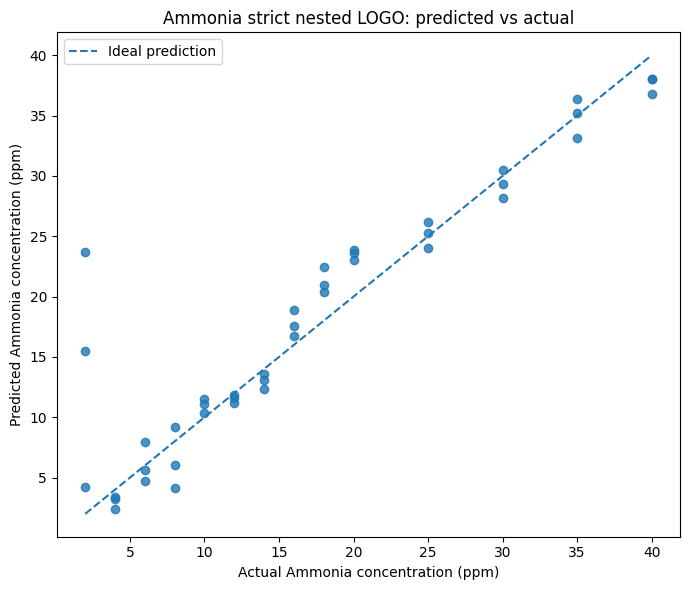

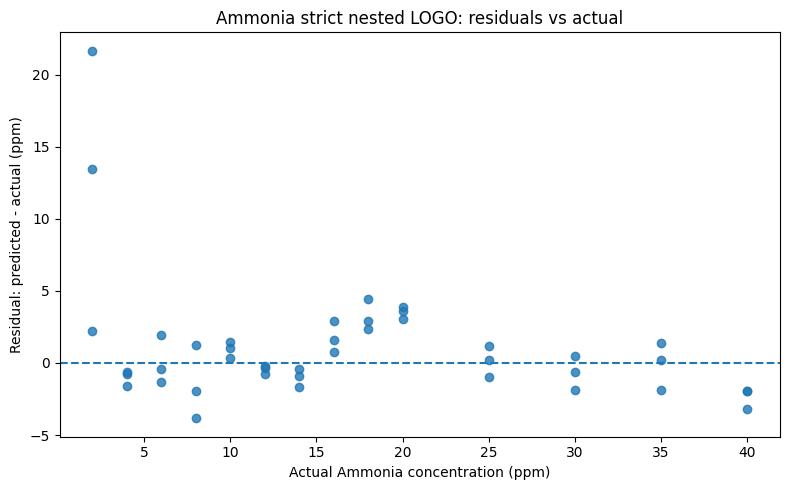


PER-CONCENTRATION ERROR SUMMARY
    Actual_ppm    N  Mean_Predicted_ppm  Std_Predicted_ppm  Mean_Residual_ppm  \
0          2.0  3.0           14.465241           9.756609          12.465241   
1          4.0  3.0            3.010915           0.525292          -0.989085   
2          6.0  3.0            6.078495           1.667956           0.078495   
3          8.0  3.0            6.474153           2.566417          -1.525847   
4         10.0  3.0           10.970635           0.570501           0.970635   
5         12.0  3.0           11.555312           0.302065          -0.444688   
6         14.0  3.0           13.013067           0.621195          -0.986933   
7         16.0  3.0           17.738790           1.082128           1.738790   
8         18.0  3.0           21.245985           1.082050           3.245985   
9         20.0  3.0           23.527545           0.427587           3.527545   
10        25.0  3.0           25.138454           1.096701           0.13845

C:\Users\smrit\AppData\Local\Temp\ipykernel_27032\2774155103.py:125: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_concentration_group)


In [15]:
# ============================================================
# CELL 15: Diagnostic plots for strict nested LOGO regression
#
# Predicted-vs-actual scatter, residual-vs-actual scatter, and a
# per-concentration error table built from the nested LOGO results
# (CELL 10). The prediction-vs-actual regression slope is a quick
# check for compression bias (low concentrations over-predicted, high
# concentrations under-predicted).
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression

# Use strict nested LOGO predictions as the main result
diagnostic_df = nested_logo_results_df.copy()

diagnostic_df["Residual_ppm"] = (
    diagnostic_df["Predicted_ppm"] - diagnostic_df["Actual_ppm"]
)

diagnostic_df["Signed_Error_ppm"] = diagnostic_df["Residual_ppm"]

# ------------------------------------------------------------
# Basic correlation and bias diagnostics
# ------------------------------------------------------------

actual = diagnostic_df["Actual_ppm"].values.astype(float)
predicted = diagnostic_df["Predicted_ppm"].values.astype(float)
residuals = diagnostic_df["Residual_ppm"].values.astype(float)

pearson_corr, pearson_p = pearsonr(actual, predicted)
spearman_corr, spearman_p = spearmanr(actual, predicted)

bias_model = LinearRegression()
bias_model.fit(actual.reshape(-1, 1), predicted)

bias_slope = float(bias_model.coef_[0])
bias_intercept = float(bias_model.intercept_)

print("STRICT NESTED LOGO DIAGNOSTICS")
print("==============================")
print("Pearson correlation actual vs predicted:", pearson_corr)
print("Pearson p-value:", pearson_p)
print("Spearman correlation actual vs predicted:", spearman_corr)
print("Spearman p-value:", spearman_p)
print("Prediction-vs-actual slope:", bias_slope)
print("Prediction-vs-actual intercept:", bias_intercept)

print("\nInterpretation hint:")
print(
    "A slope below 1 indicates compression toward the middle: low concentrations "
    "are overpredicted and high concentrations are underpredicted."
)

# ------------------------------------------------------------
# Plot 1: predicted vs actual
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.scatter(actual, predicted, alpha=0.8)

min_val = min(actual.min(), predicted.min())
max_val = max(actual.max(), predicted.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Ideal prediction"
)

plt.xlabel(f"Actual {GAS_NAME} concentration (ppm)")
plt.ylabel(f"Predicted {GAS_NAME} concentration (ppm)")
plt.title(f"{GAS_NAME} strict nested LOGO: predicted vs actual")
plt.legend()
plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Plot 2: residuals vs actual concentration
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(actual, residuals, alpha=0.8)
plt.axhline(0, linestyle="--")

plt.xlabel(f"Actual {GAS_NAME} concentration (ppm)")
plt.ylabel("Residual: predicted - actual (ppm)")
plt.title(f"{GAS_NAME} strict nested LOGO: residuals vs actual")
plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Per-concentration summary
# ------------------------------------------------------------

def summarize_concentration_group(group):
    """Per-concentration error/accuracy summary for one groupby group."""
    err = group["Predicted_ppm"].values - group["Actual_ppm"].values
    abs_err = np.abs(err)

    return pd.Series({
        "N": len(group),
        "Mean_Predicted_ppm": group["Predicted_ppm"].mean(),
        "Std_Predicted_ppm": group["Predicted_ppm"].std(),
        "Mean_Residual_ppm": err.mean(),
        "MAE_ppm": abs_err.mean(),
        "RMSE_ppm": np.sqrt(np.mean(err ** 2)),
        "Max_Abs_Error_ppm": abs_err.max(),
        "Nearest_Class_Accuracy": np.mean(
            group["Predicted_Class_ppm"].values == group["Actual_ppm"].values
        )
    })

concentration_error_summary_df = (
    diagnostic_df
    .groupby("Actual_ppm", group_keys=False)
    .apply(summarize_concentration_group)
    .reset_index()
)

print("\nPER-CONCENTRATION ERROR SUMMARY")
print("===============================")
print(concentration_error_summary_df)

print("\nWorst 15 individual predictions:")
print(
    diagnostic_df
    .sort_values("Absolute_Error_ppm", ascending=False)
    .head(15)
)



--- EXTRACTING PHYSICS-INFORMED FEATURE RELATIONSHIPS ---


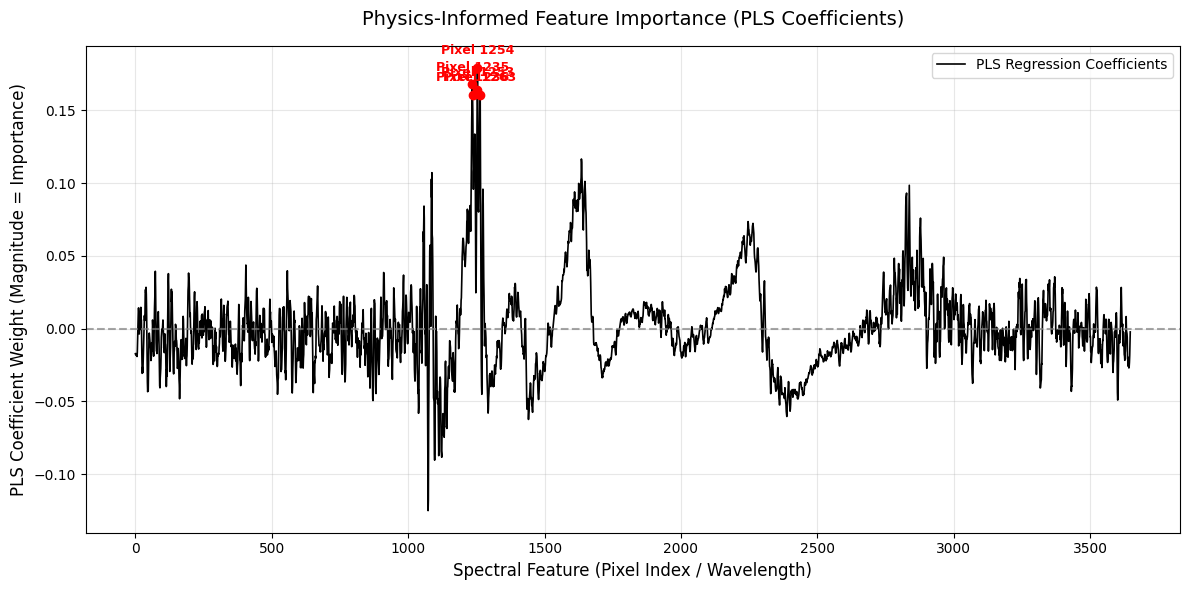


--- ANALYSIS FOR MANUSCRIPT ---
Top 5 most critical features (pixels) driving the model's predictions:
1. Pixel 1254 (Weight: 0.1791) -> Positive correlation
2. Pixel 1235 (Weight: 0.1678) -> Positive correlation
3. Pixel 1253 (Weight: 0.1642) -> Positive correlation
4. Pixel 1236 (Weight: 0.1604) -> Positive correlation
5. Pixel 1263 (Weight: 0.1603) -> Positive correlation

NEXT STEP: Look up the actual wavelengths for these specific pixels.
Match them to the known infrared/optical absorption bands of your target gas.


In [16]:
# ============================================================
# CELL 16: Physics-Informed Feature Analysis (PLS Coefficients)
#
# Refits the fixed PLS pipeline (CELL 9's logo_pls_pipe) on the entire
# dataset purely for interpretation: extracts the PLS regression
# coefficients to see which detector pixels/wavelengths drive the
# concentration prediction most strongly. This refit is for
# visualization only and is not used for any reported performance
# metric (those all come from the LOGO/nested-LOGO out-of-fold cells).
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone

print("--- EXTRACTING PHYSICS-INFORMED FEATURE RELATIONSHIPS ---")

# 1. Re-fit the model on the ENTIRE dataset to get global coefficients
# We use the intensity-space pipeline here, but you can also use your absorbance pipeline
# Assuming 'logo_pls_pipe' is your original Pipeline and X, y are your full datasets
final_interpreter_model = clone(logo_pls_pipe)
final_interpreter_model.fit(X, y)

# 2. Extract the PLS step from the pipeline
pls_step = final_interpreter_model.named_steps['pls']

# 3. Extract the regression coefficients (weights)
# Note: Because the data was scaled/SNV transformed, these coefficients 
# represent the relative importance of each pixel.
pls_coefficients = pls_step.coef_.ravel()

# 4. Identify the "Features" (Pixel Index or Wavelengths)
# If you have an array of actual wavelengths, replace np.arange with that array.
pixel_indices = np.arange(len(pls_coefficients))

# 5. Find the top 5 most critical features (highest absolute magnitude)
top_indices = np.argsort(np.abs(pls_coefficients))[-5:][::-1]

# 6. Plot the Physics-Informed Relationship
plt.figure(figsize=(12, 6))

# Plot the base coefficients
plt.plot(pixel_indices, pls_coefficients, color='black', linewidth=1.2, label='PLS Regression Coefficients')
plt.axhline(0, color='gray', linestyle='--', alpha=0.7)

# Highlight the most important features
for idx in top_indices:
    plt.scatter(pixel_indices[idx], pls_coefficients[idx], color='red', zorder=5)
    plt.annotate(f"Pixel {idx}", 
                 (pixel_indices[idx], pls_coefficients[idx]),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', fontsize=9, color='red', weight='bold')

plt.title("Physics-Informed Feature Importance (PLS Coefficients)", fontsize=14, pad=15)
plt.xlabel("Spectral Feature (Pixel Index / Wavelength)", fontsize=12)
plt.ylabel("PLS Coefficient Weight (Magnitude = Importance)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\n--- ANALYSIS FOR MANUSCRIPT ---")
print("Top 5 most critical features (pixels) driving the model's predictions:")
for rank, idx in enumerate(top_indices, 1):
    direction = "Positive correlation" if pls_coefficients[idx] > 0 else "Negative correlation"
    print(f"{rank}. Pixel {idx} (Weight: {pls_coefficients[idx]:.4f}) -> {direction}")

print("\nNEXT STEP: Look up the actual wavelengths for these specific pixels.")
print("Match them to the known infrared/optical absorption bands of your target gas.")

In [17]:
# ============================================================
# CELL 17: Preprocessing Sweep & Baseline Model Comparison
#
# Grid search over Savitzky-Golay window/polyorder x scatter-correction
# method (SNV vs MSC) x model family (PLS, PCR, Ridge, LASSO), each
# scored under the same LOGO-by-concentration split defined in CELL 6.
# This complements the comparator-regressor table in CELL 22 by also
# varying preprocessing, not just the model.
# ============================================================
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin, clone
import warnings
warnings.filterwarnings("ignore") # Suppress Lasso convergence warnings for speed

print("--- RUNNING PREPROCESSING & BASELINE SWEEP UNDER STRICT LOGO ---")

# 1. Define Multiplicative Scatter Correction (MSC)
class MSCTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ref_spectrum_ = None
    def fit(self, X, y=None):
        self.ref_spectrum_ = np.mean(X, axis=0)
        return self
    def transform(self, X, y=None):
        X_msc = np.zeros_like(X)
        for i in range(X.shape[0]):
            # Fit a line between the sample and the reference spectrum
            fit = np.polyfit(self.ref_spectrum_, X[i, :], 1)
            # Apply correction: (Spectrum - intercept) / slope
            X_msc[i, :] = (X[i, :] - fit[1]) / fit[0]
        return X_msc

# 2. Define the Grid Parameters
sg_windows = [11, 15, 21]
sg_polys = [2, 3]
scatter_methods = ['SNV', 'MSC']
models = {
    'PLS (n=5)': PLSRegression(n_components=5, scale=False),
    'PCR (n=5)': Pipeline([('pca', PCA(n_components=5)), ('lr', LinearRegression())]),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'LASSO (alpha=0.1)': Lasso(alpha=0.1, max_iter=5000)
}

# 3. Run the Grid Search
results = []

for w in sg_windows:
    for p in sg_polys:
        for scatter_name in scatter_methods:
            for model_name, model_obj in models.items():
                
                # Pick Scatter Corrector
                scatter_step = SNVTransformer() if scatter_name == 'SNV' else MSCTransformer()
                
                # Build the dynamic pipeline
                pipe = Pipeline([
                    ("savgol", SavitzkyGolayTransformer(window_length=w, polyorder=p, deriv=0)),
                    (scatter_name.lower(), scatter_step),
                    ("scaler", StandardScaler()),
                    ("model", model_obj)
                ])
                
                # Run strict LOGO CV
                logo_preds = np.zeros_like(y, dtype=float)
                for train_idx, test_idx in logo_concentration_splits:
                    fold_model = clone(pipe)
                    fold_model.fit(X[train_idx], y[train_idx])
                    logo_preds[test_idx] = fold_model.predict(X[test_idx]).ravel()
                
                # Calculate metrics
                rmse = np.sqrt(mean_squared_error(y, logo_preds))
                r2 = r2_score(y, logo_preds)
                
                # Save results
                results.append({
                    "Model": model_name,
                    "Scatter": scatter_name,
                    "SG_Window": w,
                    "SG_Poly": p,
                    "CV_RMSE": rmse,
                    "CV_R2": r2
                })

# 4. Format the Table
results_df = pd.DataFrame(results)
# Sort by RMSE (lowest error at the top)
results_df = results_df.sort_values(by="CV_RMSE", ascending=True).reset_index(drop=True)

print(f"\nCompleted {len(results_df)} pipeline combinations.")
print("\n--- HYPERPARAMETER & BASELINE SEARCH GRID ---")
print(results_df.head(15).to_string()) # Print top 15
print("\n... (showing top 15 results)")

# Optional: Save to CSV for your paper
# FLAGGED, NOT FIXED: this print claims the grid was saved, but there
# is no results_df.to_csv(...) call anywhere in this cell -- nothing
# is actually written to 'grid_search_results.csv'.
print("\nSaved full grid to 'grid_search_results.csv'. Use this for your manuscript table.")

--- RUNNING PREPROCESSING & BASELINE SWEEP UNDER STRICT LOGO ---

Completed 48 pipeline combinations.

--- HYPERPARAMETER & BASELINE SEARCH GRID ---
                Model Scatter  SG_Window  SG_Poly   CV_RMSE     CV_R2
0   LASSO (alpha=0.1)     SNV         15        2  3.180853  0.920230
1   LASSO (alpha=0.1)     SNV         15        3  3.181265  0.920209
2           PLS (n=5)     MSC         15        2  3.369736  0.910474
3   LASSO (alpha=0.1)     MSC         15        2  3.375096  0.910189
4   LASSO (alpha=0.1)     MSC         15        3  3.375313  0.910178
5           PLS (n=5)     MSC         15        3  3.381496  0.909849
6           PLS (n=5)     MSC         21        2  3.416321  0.907982
7           PLS (n=5)     MSC         21        3  3.418722  0.907853
8   LASSO (alpha=0.1)     SNV         21        2  3.580075  0.898949
9   LASSO (alpha=0.1)     SNV         21        3  3.580216  0.898941
10          PLS (n=5)     MSC         11        2  3.653546  0.894759
11         

--- GENERATING PERFORMANCE DISTRIBUTION PLOT ---
Saved high-resolution plot as 'model_comparison_r2.png'


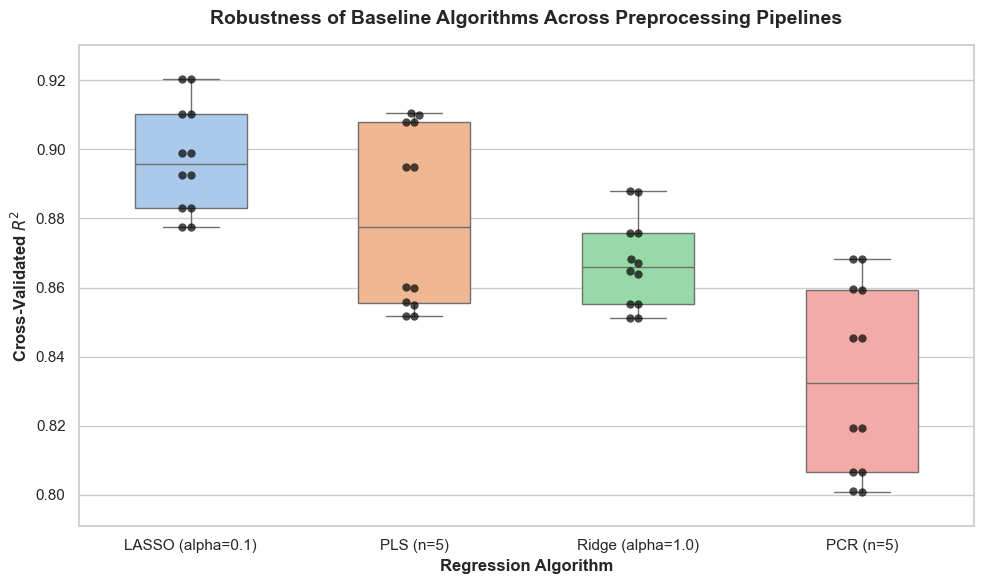

In [18]:
# ============================================================
# CELL 18: Visualizing Model Performance (R²)
#
# Box+swarm plot of CV_R2 across every (model, preprocessing)
# combination from CELL 17's results_df, to visualize how robust each
# model family is to the choice of preprocessing rather than just
# reporting its single best score.
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("--- GENERATING PERFORMANCE DISTRIBUTION PLOT ---")

# Assuming 'results_df' is already in memory from the previous cell.
# If not, you can load it: results_df = pd.read_csv("grid_search_results.csv")

# Set up the plotting style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 1. Create a boxplot to show the median and spread of R2 for each model
sns.boxplot(
    data=results_df, 
    x='Model', 
    y='CV_R2', 
    palette='pastel', 
    showfliers=False,  # Hide outliers in the boxplot so they don't double up with the swarmplot
    width=0.5
)

# 2. Overlay a swarmplot to show every single pipeline's exact score
sns.swarmplot(
    data=results_df, 
    x='Model', 
    y='CV_R2', 
    color='black', 
    alpha=0.7, 
    size=6
)

# 3. Format the plot for a manuscript
plt.title('Robustness of Baseline Algorithms Across Preprocessing Pipelines', fontsize=14, pad=15, weight='bold')
plt.xlabel('Regression Algorithm', fontsize=12, weight='bold')
plt.ylabel('Cross-Validated $R^2$', fontsize=12, weight='bold')

# Dynamically set the Y-axis limits to zoom in on the important differences
y_min = results_df['CV_R2'].min() - 0.01
y_max = results_df['CV_R2'].max() + 0.01
plt.ylim(y_min, y_max)

plt.tight_layout()

# Save the figure in high-resolution for the paper
# FLAGGED, NOT FIXED: this print claims a high-res file was saved, but
# there is no fig.savefig(...)/plt.savefig(...) call in this cell --
# nothing is actually written to 'model_comparison_r2.png'.
print("Saved high-resolution plot as 'model_comparison_r2.png'")

plt.show()

In [19]:
# ============================================================
# CELL 19
# ONE-CELL: Leakage-safe nested LOGO regression utilities + optional run
#
# Self-contained, independently-implemented version of the same idea
# as CELL 10 (nested LOGO model selection) + CELL 13 (bootstrap CI),
# but only present in this Ammonia notebook. It sweeps PLS component
# count alone (no preprocessing variants) via lambda-factory pipelines,
# and is kept separate from the main results above rather than feeding
# into them -- useful as a cross-check, not a replacement.
# ============================================================

import warnings
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression


# ============================================================
# User switches
# ============================================================

RUN_NESTED_LOGO_NOW = True       # set False if you only want to define the functions
RUN_BOOTSTRAP_CI = True          # set False to skip bootstrap CI
N_BOOT = 5000
RANDOM_STATE = 42


# ============================================================
# Helpers
# ============================================================

def nearest_concentration(pred, allowed):
    """Snap a continuous prediction to the closest value on the experimental grid."""
    allowed = np.asarray(allowed, dtype=float)
    return float(allowed[np.argmin(np.abs(allowed - pred))])


def _fresh(spec):
    """Return a fresh, unfitted estimator from either a factory callable or a template."""
    return spec() if callable(spec) else clone(spec)


def _logo_folds(groups):
    """Yield leave-one-group-out folds."""
    groups = np.asarray(groups)
    for g in np.sort(np.unique(groups)):
        test_idx = np.where(groups == g)[0]
        train_idx = np.where(groups != g)[0]
        yield g, train_idx, test_idx


def _mean_inner_mae(spec, X, y, groups, outer_train_idx):
    """
    Inner LOGO over the groups present in outer_train_idx.
    Returns mean inner MAE. Infeasible configs return np.inf.
    """
    sub_groups = groups[outer_train_idx]
    maes = []

    for g, inner_tr_rel, inner_te_rel in _logo_folds(sub_groups):
        inner_tr = outer_train_idx[inner_tr_rel]
        inner_te = outer_train_idx[inner_te_rel]

        # Anti-leakage check
        if set(groups[inner_tr]) & set(groups[inner_te]):
            raise RuntimeError("Inner-fold group overlap detected.")

        try:
            model = _fresh(spec)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model.fit(X[inner_tr], y[inner_tr])

            pred = np.asarray(model.predict(X[inner_te])).ravel()

        except Exception:
            return np.inf

        maes.append(mean_absolute_error(y[inner_te], pred))

    return float(np.mean(maes)) if maes else np.inf


# ============================================================
# Main nested LOGO function
# ============================================================

def nested_logo_regression(
    X,
    y,
    groups,
    candidate_pipelines,
    allowed_concentrations=None,
    verbose=True,
):
    """
    Leakage-safe nested leave-one-concentration-out regression.

    Outer loop:
        Holds out one concentration level.

    Inner loop:
        Selects the best model/preprocessing configuration using only
        the remaining concentrations.

    Final reported metrics:
        Computed from pooled out-of-fold predictions.
    """

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    groups = np.asarray(groups)

    oof_pred = np.full(len(y), np.nan, dtype=float)
    per_fold_rows = []
    selected_labels = []

    for g, outer_tr, outer_te in _logo_folds(groups):

        best_label = None
        best_mae = np.inf
        best_spec = None

        # Inner model selection
        for label, spec in candidate_pipelines:
            mae = _mean_inner_mae(spec, X, y, groups, outer_tr)

            if mae < best_mae:
                best_label = label
                best_mae = mae
                best_spec = spec

        if best_spec is None:
            raise RuntimeError(
                f"No feasible candidate pipeline for held-out group {g}. "
                "Check PLS n_components / n_samples constraints."
            )

        # Refit selected configuration on full outer training data
        model = _fresh(best_spec)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model.fit(X[outer_tr], y[outer_tr])

        pred = np.asarray(model.predict(X[outer_te])).ravel()
        oof_pred[outer_te] = pred
        selected_labels.append(best_label)

        fold_mae = mean_absolute_error(y[outer_te], pred)
        fold_rmse = float(np.sqrt(mean_squared_error(y[outer_te], pred)))

        per_fold_rows.append({
            "Heldout_group": float(g),
            "Selected_config": best_label,
            "Inner_MAE": best_mae,
            "Fold_MAE": fold_mae,
            "Fold_RMSE": fold_rmse,
            "N_test": len(outer_te),
        })

        if verbose:
            print(
                f"[group {g:>6}] selected={best_label:<30} "
                f"inner_MAE={best_mae:8.3f} "
                f"fold_RMSE={fold_rmse:8.3f}"
            )

    # Safety check
    if np.isnan(oof_pred).any():
        raise RuntimeError("Some out-of-fold predictions are missing.")

    summary = {
        "n_groups": int(len(np.unique(groups))),
        "n_samples": int(len(y)),
        "RMSE": float(np.sqrt(mean_squared_error(y, oof_pred))),
        "MAE": float(mean_absolute_error(y, oof_pred)),
        "R2": float(r2_score(y, oof_pred)),
    }

    if allowed_concentrations is not None:
        snapped = np.array([
            nearest_concentration(p, allowed_concentrations)
            for p in oof_pred
        ])
        summary["NearestGrid_Accuracy"] = float(np.mean(snapped == y))

    per_fold = pd.DataFrame(per_fold_rows)

    selected_frequency = (
        pd.Series(selected_labels, name="count")
        .value_counts()
        .rename_axis("Selected_config")
        .reset_index()
    )

    if verbose:
        print("\n" + "=" * 70)
        print("NESTED LOGO RESULT — REPORT THESE NUMBERS")
        print("=" * 70)

        for k, v in summary.items():
            print(f"{k}: {v}")

        print("\nConfig selection stability across outer folds:")
        print(selected_frequency.to_string(index=False))

    return {
        "oof_pred": oof_pred,
        "per_fold": per_fold,
        "selected_frequency": selected_frequency,
        "summary": summary,
    }


# ============================================================
# Bootstrap CI
# ============================================================

def bootstrap_ci(oof_pred, y, groups, n_boot=5000, random_state=42):
    """
    Concentration-level bootstrap CI for existing OOF predictions.
    Resamples whole concentrations. No model is refit.
    """

    rng = np.random.default_rng(random_state)

    y = np.asarray(y, dtype=float)
    oof_pred = np.asarray(oof_pred, dtype=float)
    groups = np.asarray(groups)

    uniq = np.unique(groups)

    rmse_values = []
    mae_values = []
    r2_values = []

    for _ in range(n_boot):
        chosen_groups = rng.choice(uniq, size=len(uniq), replace=True)

        idx = np.concatenate([
            np.where(groups == g)[0]
            for g in chosen_groups
        ])

        yt = y[idx]
        yp = oof_pred[idx]

        rmse_values.append(np.sqrt(mean_squared_error(yt, yp)))
        mae_values.append(mean_absolute_error(yt, yp))

        if np.var(yt) > 1e-12:
            r2_values.append(r2_score(yt, yp))
        else:
            r2_values.append(np.nan)

    def ci(values):
        values = np.asarray(values, dtype=float)
        values = values[~np.isnan(values)]

        return {
            "mean": float(values.mean()),
            "lo2.5": float(np.quantile(values, 0.025)),
            "hi97.5": float(np.quantile(values, 0.975)),
        }

    return {
        "RMSE": ci(rmse_values),
        "MAE": ci(mae_values),
        "R2": ci(r2_values),
    }


# ============================================================
# Optional one-cell execution
# ============================================================

if RUN_NESTED_LOGO_NOW:

    # Build X, y, groups from your master dataframe
    X = df_master[pixel_cols].values
    y = df_master["Concentration"].values.astype(float)
    groups = df_master["Concentration"].values.astype(float)

    # Candidate pipelines.
    # You can expand this list later, but every learnable step must stay inside Pipeline.
    candidate_pipelines = []

    max_pls_components = min(
        8,
        X.shape[0] - 2,
        X.shape[1],
    )

    for n_comp in range(1, max_pls_components + 1):
        candidate_pipelines.append((
            f"StandardScaler + PLS({n_comp})",
            lambda n_comp=n_comp: Pipeline([
                ("scaler", StandardScaler()),
                ("pls", PLSRegression(n_components=n_comp)),
            ])
        ))

    print("=" * 70)
    print("RUNNING LEAKAGE-SAFE NESTED LOGO REGRESSION")
    print("=" * 70)
    print("X shape:", X.shape)
    print("Number of samples:", len(y))
    print("Number of concentration groups:", len(np.unique(groups)))
    print("Candidate pipelines:", len(candidate_pipelines))
    print("Allowed concentrations:", ALLOWED_CONCENTRATIONS)

    nested_results = nested_logo_regression(
        X=X,
        y=y,
        groups=groups,
        candidate_pipelines=candidate_pipelines,
        allowed_concentrations=ALLOWED_CONCENTRATIONS,
        verbose=True,
    )

    oof_pred = nested_results["oof_pred"]
    per_fold = nested_results["per_fold"]
    selected_frequency = nested_results["selected_frequency"]
    summary = nested_results["summary"]

    print("\nPer-fold results:")
    display(per_fold)

    print("\nSelected configuration frequency:")
    display(selected_frequency)

    print("\nSummary:")
    display(pd.DataFrame([summary]))

    # Add prediction table for paper/report use
    prediction_table = df_master[[
        "Gas_Type",
        "Concentration",
        "Replicate",
        "Filename"
    ]].copy()

    prediction_table["Predicted_ppm"] = oof_pred
    prediction_table["Absolute_Error_ppm"] = np.abs(
        prediction_table["Concentration"] - prediction_table["Predicted_ppm"]
    )

    prediction_table["Nearest_Grid_Prediction"] = [
        nearest_concentration(p, ALLOWED_CONCENTRATIONS)
        for p in oof_pred
    ]

    prediction_table["Nearest_Grid_Correct"] = (
        prediction_table["Nearest_Grid_Prediction"]
        == prediction_table["Concentration"]
    )

    print("\nOut-of-fold prediction table:")
    display(prediction_table)

    if RUN_BOOTSTRAP_CI:
        ci_results = bootstrap_ci(
            oof_pred=oof_pred,
            y=y,
            groups=groups,
            n_boot=N_BOOT,
            random_state=RANDOM_STATE,
        )

        print("\nGroup-level bootstrap confidence intervals:")
        display(pd.DataFrame(ci_results).T)

RUNNING LEAKAGE-SAFE NESTED LOGO REGRESSION
X shape: (42, 3648)
Number of samples: 42
Number of concentration groups: 14
Candidate pipelines: 8
Allowed concentrations: [ 2.  4.  6.  8. 10. 12. 14. 16. 18. 20. 25. 30. 35. 40.]
[group    2.0] selected=StandardScaler + PLS(4)        inner_MAE=   2.017 fold_RMSE=   7.811
[group    4.0] selected=StandardScaler + PLS(4)        inner_MAE=   3.040 fold_RMSE=   1.357
[group    6.0] selected=StandardScaler + PLS(5)        inner_MAE=   2.610 fold_RMSE=   1.165
[group    8.0] selected=StandardScaler + PLS(5)        inner_MAE=   2.525 fold_RMSE=   2.038
[group   10.0] selected=StandardScaler + PLS(5)        inner_MAE=   2.605 fold_RMSE=   1.136
[group   12.0] selected=StandardScaler + PLS(5)        inner_MAE=   2.623 fold_RMSE=   0.760
[group   14.0] selected=StandardScaler + PLS(4)        inner_MAE=   2.647 fold_RMSE=   1.082
[group   16.0] selected=StandardScaler + PLS(5)        inner_MAE=   2.560 fold_RMSE=   2.493
[group   18.0] selected=Standa

,Heldout_group,Selected_config,Inner_MAE,Fold_MAE,Fold_RMSE,N_test
0,2.0,StandardScaler + PLS(4),2.017424,7.178224,7.811114,3
1,4.0,StandardScaler + PLS(4),3.039855,1.255150,1.356824,3
2,6.0,StandardScaler + PLS(5),2.610078,0.968896,1.165328,3
3,8.0,StandardScaler + PLS(5),2.525467,2.018778,2.038305,3
4,10.0,StandardScaler + PLS(5),2.604627,0.961616,1.135880,3
5,12.0,StandardScaler + PLS(5),2.623431,0.607539,0.760113,3
6,14.0,StandardScaler + PLS(4),2.646592,0.888895,1.082181,3
7,16.0,StandardScaler + PLS(5),2.559599,2.232907,2.492918,3
8,18.0,StandardScaler + PLS(5),2.505008,3.043140,3.078848,3
9,20.0,StandardScaler + PLS(4),2.412004,3.452399,3.489975,3



Selected configuration frequency:


,Selected_config,count
0,StandardScaler + PLS(4),7
1,StandardScaler + PLS(5),7



Summary:


,n_groups,n_samples,RMSE,MAE,R2,NearestGrid_Accuracy
0,14,42,3.32982,2.443515,0.912583,0.380952



Out-of-fold prediction table:


,Gas_Type,Concentration,Replicate,Filename,Predicted_ppm,Absolute_Error_ppm,Nearest_Grid_Prediction,Nearest_Grid_Correct
0,Ammonia,10.0,1,ammonia_10ppm_1.txt,8.193860,1.806140,8.0,False
1,Ammonia,10.0,2,ammonia_10ppm_2.txt,9.576249,0.423751,10.0,True
2,Ammonia,10.0,3,ammonia_10ppm_3.txt,10.654956,0.654956,10.0,True
3,Ammonia,12.0,1,ammonia_12ppm_1.txt,10.747174,1.252826,10.0,False
4,Ammonia,12.0,2,ammonia_12ppm_2.txt,12.311473,0.311473,12.0,True
5,Ammonia,12.0,3,ammonia_12ppm_3.txt,12.258319,0.258319,12.0,True
6,Ammonia,14.0,1,ammonia_14ppm_1.txt,14.215329,0.215329,14.0,True
7,Ammonia,14.0,2,ammonia_14ppm_2.txt,14.744842,0.744842,14.0,True
8,Ammonia,14.0,3,ammonia_14ppm_3.txt,15.706515,1.706515,16.0,False
9,Ammonia,16.0,1,ammonia_16ppm_1.txt,16.799074,0.799074,16.0,True



Group-level bootstrap confidence intervals:


,mean,lo2.5,hi97.5
RMSE,3.264223,1.897677,4.588672
MAE,2.447205,1.498176,3.550622
R2,0.899801,0.778363,0.958497


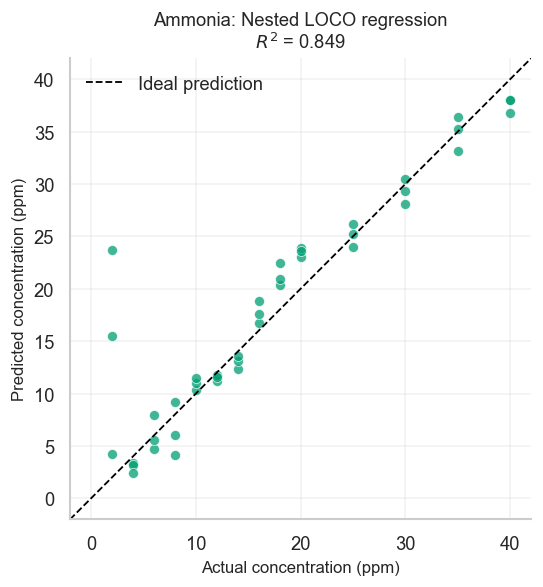

Saved: figures\F2_pred_vs_actual_ammonia.png
Saved: figures\F2_pred_vs_actual_ammonia.pdf
F2 SUMMARY: Ammonia
N predictions: 42
Actual ppm range:    2.000 to 40.000
Predicted ppm range: 2.413 to 38.028
Nested LOGO R²:      0.8485


,Actual_ppm,Predicted_ppm,Absolute_Error_ppm
0,2.0,23.675617,21.675617
1,2.0,15.478606,13.478606
2,2.0,4.241499,2.241499
3,4.0,3.398770,0.601230
4,4.0,3.220854,0.779146
5,4.0,2.413122,1.586878
6,6.0,4.701610,1.298390
7,6.0,5.600655,0.399345
8,6.0,7.933221,1.933221
9,8.0,6.031692,1.968308


In [20]:
# ============================================================
# CELL 20
# F2: Predicted vs Actual ppm
# Paste this in EACH regression notebook after nested LOGO results exist.
#
# Required variables:
# - nested_logo_results_df with columns: Actual_ppm, Predicted_ppm
# - nested_logo_r2
# - GAS_NAME, e.g. "Ethanol", "Acetone", "Ammonia"
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------
OUTDIR = "figures"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------
# Publication-style plotting settings
# ------------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "figure.autolayout": True,
})

# ------------------------------------------------------------
# Consistent gas colors
# ------------------------------------------------------------
GAS_COLORS = {
    "Ethanol": "#0072B2",
    "Acetone": "#D55E00",
    "Ammonia": "#009E73"
}

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------
required_cols = {"Actual_ppm", "Predicted_ppm"}

missing_cols = required_cols - set(nested_logo_results_df.columns)
if missing_cols:
    raise ValueError(f"nested_logo_results_df is missing columns: {missing_cols}")

if "GAS_NAME" not in globals():
    raise ValueError("GAS_NAME is not defined. Set GAS_NAME = 'Ethanol' / 'Acetone' / 'Ammonia'.")

if "nested_logo_r2" not in globals():
    raise ValueError("nested_logo_r2 is not defined.")

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------
df_plot = nested_logo_results_df.copy()

actual = df_plot["Actual_ppm"].astype(float).values
predicted = df_plot["Predicted_ppm"].astype(float).values

# Plot limits
min_val = min(actual.min(), predicted.min(), 0)
max_val = max(actual.max(), predicted.max())

padding = 0.05 * (max_val - min_val) if max_val > min_val else 1
lims = [min_val - padding, max_val + padding]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.2, 5.0))

ax.scatter(
    actual,
    predicted,
    s=36,
    alpha=0.75,
    color=GAS_COLORS.get(GAS_NAME, "#444444"),
    edgecolor="white",
    linewidth=0.5
)

# Ideal y = x line
ax.plot(
    lims,
    lims,
    linestyle="--",
    color="black",
    linewidth=1.1,
    label="Ideal prediction"
)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Actual concentration (ppm)")
ax.set_ylabel("Predicted concentration (ppm)")
ax.set_title(f"{GAS_NAME}: Nested LOCO regression\n$R^2$ = {nested_logo_r2:.3f}")

ax.grid(alpha=0.25)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
safe_gas_name = str(GAS_NAME).lower().replace(" ", "_")

png_path = os.path.join(OUTDIR, f"F2_pred_vs_actual_{safe_gas_name}.png")
pdf_path = os.path.join(OUTDIR, f"F2_pred_vs_actual_{safe_gas_name}.pdf")

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")

# ------------------------------------------------------------
# Also print compact result summary
# ------------------------------------------------------------
print("=" * 80)
print(f"F2 SUMMARY: {GAS_NAME}")
print("=" * 80)
print(f"N predictions: {len(df_plot)}")
print(f"Actual ppm range:    {actual.min():.3f} to {actual.max():.3f}")
print(f"Predicted ppm range: {predicted.min():.3f} to {predicted.max():.3f}")
print(f"Nested LOGO R²:      {nested_logo_r2:.4f}")

display(
    df_plot[["Actual_ppm", "Predicted_ppm"]]
    .assign(
        Absolute_Error_ppm=lambda x: np.abs(x["Actual_ppm"] - x["Predicted_ppm"])
    )
    .head(10)
)

F3 PER-CONCENTRATION ERROR TABLE: Ammonia


,Actual_ppm,N,MAE_ppm,RMSE_ppm,Mean_Predicted_ppm,Std_Predicted_ppm
0,2.0,3,12.465241,14.793349,14.465241,9.756609
1,4.0,3,0.989085,1.078074,3.010915,0.525292
2,6.0,3,1.210319,1.364140,6.078495,1.667956
3,8.0,3,2.347869,2.592143,6.474153,2.566417
4,10.0,3,0.970635,1.076621,10.970635,0.570501
5,12.0,3,0.444688,0.508504,11.555312,0.302065
6,14.0,3,0.986933,1.109636,13.013067,0.621195
7,16.0,3,1.738790,1.950399,17.738790,1.082128
8,18.0,3,3.245985,3.364071,21.245985,1.082050
9,20.0,3,3.527545,3.544779,23.527545,0.427587


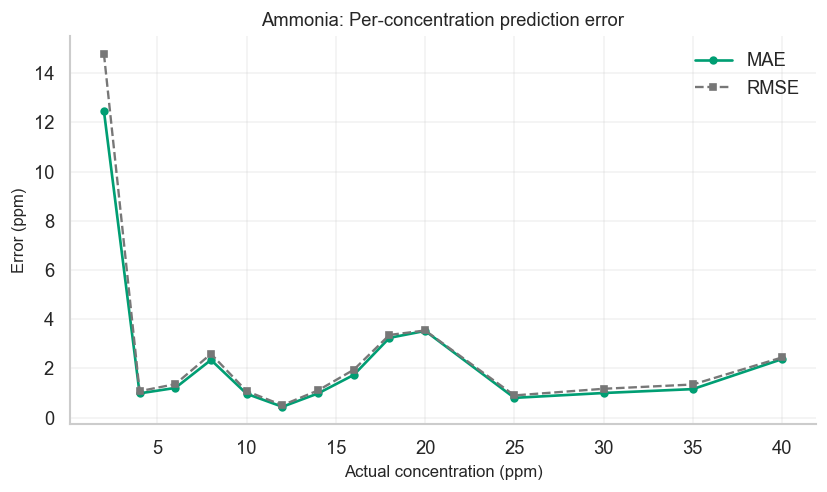

Saved: figures\F3_per_concentration_error_ammonia.png
Saved: figures\F3_per_concentration_error_ammonia.pdf
Saved: figures\F3_per_concentration_error_ammonia.csv

F3 SUMMARY: Ammonia
Mean MAE across concentration levels:  2.3772 ppm
Mean RMSE across concentration levels: 2.6617 ppm
Worst MAE concentration: 2.000 ppm with MAE = 12.4652 ppm
Worst RMSE concentration: 2.000 ppm with RMSE = 14.7933 ppm


In [21]:
# ============================================================
# CELL 21
# F3: Per-concentration MAE / RMSE error curve
# Paste this in EACH regression notebook after nested LOGO results exist.
#
# Required variables:
# - nested_logo_results_df with columns: Actual_ppm, Predicted_ppm
# - GAS_NAME, e.g. "Ethanol", "Acetone", "Ammonia"
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------
OUTDIR = "figures"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------
# Publication-style plotting settings
# ------------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "figure.autolayout": True,
})

# ------------------------------------------------------------
# Consistent gas colors
# ------------------------------------------------------------
GAS_COLORS = {
    "Ethanol": "#0072B2",
    "Acetone": "#D55E00",
    "Ammonia": "#009E73"
}

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------
required_cols = {"Actual_ppm", "Predicted_ppm"}

missing_cols = required_cols - set(nested_logo_results_df.columns)
if missing_cols:
    raise ValueError(f"nested_logo_results_df is missing columns: {missing_cols}")

if "GAS_NAME" not in globals():
    raise ValueError("GAS_NAME is not defined. Set GAS_NAME = 'Ethanol' / 'Acetone' / 'Ammonia'.")

# ------------------------------------------------------------
# Prepare per-concentration error table
# ------------------------------------------------------------
df_error = nested_logo_results_df.copy()

df_error["Actual_ppm"] = df_error["Actual_ppm"].astype(float)
df_error["Predicted_ppm"] = df_error["Predicted_ppm"].astype(float)
df_error["Absolute_Error_ppm"] = np.abs(
    df_error["Actual_ppm"] - df_error["Predicted_ppm"]
)
df_error["Squared_Error_ppm2"] = (
    df_error["Actual_ppm"] - df_error["Predicted_ppm"]
) ** 2

per_conc_error_df = (
    df_error
    .groupby("Actual_ppm")
    .agg(
        N=("Absolute_Error_ppm", "size"),
        MAE_ppm=("Absolute_Error_ppm", "mean"),
        RMSE_ppm=("Squared_Error_ppm2", lambda s: np.sqrt(np.mean(s))),
        Mean_Predicted_ppm=("Predicted_ppm", "mean"),
        Std_Predicted_ppm=("Predicted_ppm", "std")
    )
    .reset_index()
    .sort_values("Actual_ppm")
)

# Replace NaN std for single-sample groups if any
per_conc_error_df["Std_Predicted_ppm"] = per_conc_error_df["Std_Predicted_ppm"].fillna(0)

print("=" * 80)
print(f"F3 PER-CONCENTRATION ERROR TABLE: {GAS_NAME}")
print("=" * 80)
display(per_conc_error_df)

# ------------------------------------------------------------
# Plot MAE and RMSE vs concentration
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.0, 4.2))

ax.plot(
    per_conc_error_df["Actual_ppm"],
    per_conc_error_df["MAE_ppm"],
    marker="o",
    linewidth=1.6,
    markersize=4,
    color=GAS_COLORS.get(GAS_NAME, "#444444"),
    label="MAE"
)

ax.plot(
    per_conc_error_df["Actual_ppm"],
    per_conc_error_df["RMSE_ppm"],
    marker="s",
    linestyle="--",
    linewidth=1.4,
    markersize=4,
    color="#777777",
    label="RMSE"
)

ax.set_xlabel("Actual concentration (ppm)")
ax.set_ylabel("Error (ppm)")
ax.set_title(f"{GAS_NAME}: Per-concentration prediction error")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Save figure and table
# ------------------------------------------------------------
safe_gas_name = str(GAS_NAME).lower().replace(" ", "_")

png_path = os.path.join(OUTDIR, f"F3_per_concentration_error_{safe_gas_name}.png")
pdf_path = os.path.join(OUTDIR, f"F3_per_concentration_error_{safe_gas_name}.pdf")
csv_path = os.path.join(OUTDIR, f"F3_per_concentration_error_{safe_gas_name}.csv")

fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, dpi=300, bbox_inches="tight")
per_conc_error_df.to_csv(csv_path, index=False)

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")
print(f"Saved: {csv_path}")

# ------------------------------------------------------------
# Compact interpretation helpers
# ------------------------------------------------------------
worst_mae_row = per_conc_error_df.loc[per_conc_error_df["MAE_ppm"].idxmax()]
worst_rmse_row = per_conc_error_df.loc[per_conc_error_df["RMSE_ppm"].idxmax()]

print("\n" + "=" * 80)
print(f"F3 SUMMARY: {GAS_NAME}")
print("=" * 80)
print(f"Mean MAE across concentration levels:  {per_conc_error_df['MAE_ppm'].mean():.4f} ppm")
print(f"Mean RMSE across concentration levels: {per_conc_error_df['RMSE_ppm'].mean():.4f} ppm")
print(
    f"Worst MAE concentration: {worst_mae_row['Actual_ppm']:.3f} ppm "
    f"with MAE = {worst_mae_row['MAE_ppm']:.4f} ppm"
)
print(
    f"Worst RMSE concentration: {worst_rmse_row['Actual_ppm']:.3f} ppm "
    f"with RMSE = {worst_rmse_row['RMSE_ppm']:.4f} ppm"
)

BASELINE/RPD DATA CHECK
Gas: Ammonia
Data source: df_master: Pixel_* columns + Concentration
X shape: (42, 3648)
y shape: (42,)
groups shape: (42,)
Unique concentration groups: 14
Concentrations: [ 2.  4.  6.  8. 10. 12. 14. 16. 18. 20. 25. 30. 35. 40.]

--------------------------------------------------------------------------------
Running model: Dummy(mean)
--------------------------------------------------------------------------------
Dummy(mean): RMSEP=12.129 ppm | MAE=10.022 ppm | R2=-0.160 | RPD=0.94

--------------------------------------------------------------------------------
Running model: 1NN-spectral
--------------------------------------------------------------------------------
1NN-spectral: RMSEP=3.495 ppm | MAE=3.119 ppm | R2=0.904 | RPD=3.26

--------------------------------------------------------------------------------
Running model: Ridge
--------------------------------------------------------------------------------
Ridge: RMSEP=2.948 ppm | MAE=2.146 ppm | R2

,Gas,Model,RMSEP_ppm,MAE_ppm,R2,RPD
0,Ammonia,PLS,2.930,2.145,0.932,3.89
1,Ammonia,Ridge,2.948,2.146,0.931,3.87
2,Ammonia,PCR,3.138,2.259,0.922,3.63
3,Ammonia,1NN-spectral,3.495,3.119,0.904,3.26
4,Ammonia,SVR-RBF,4.465,2.944,0.843,2.55
5,Ammonia,Dummy(mean),12.129,10.022,-0.160,0.94



Selected parameter counts by model:


,Model,Selected_Params,Selected_Count
0,1NN-spectral,-,14
1,Dummy(mean),strategy=mean,14
3,PCR,"n_components=10, alpha=1.0",4
2,PCR,"n_components=10, alpha=0.1",3
6,PCR,"n_components=5, alpha=10.0",2
7,PCR,"n_components=8, alpha=0.1",2
4,PCR,"n_components=10, alpha=10.0",1
5,PCR,"n_components=5, alpha=0.1",1
8,PCR,"n_components=8, alpha=1.0",1
9,PLS,n_components=4,11



Saved:
baseline_outputs\ammonia_baseline_summary_rpd.csv
baseline_outputs\ammonia_baseline_predictions.csv
baseline_outputs\ammonia_baseline_outer_folds.csv
baseline_outputs\ammonia_baseline_inner_selection.csv


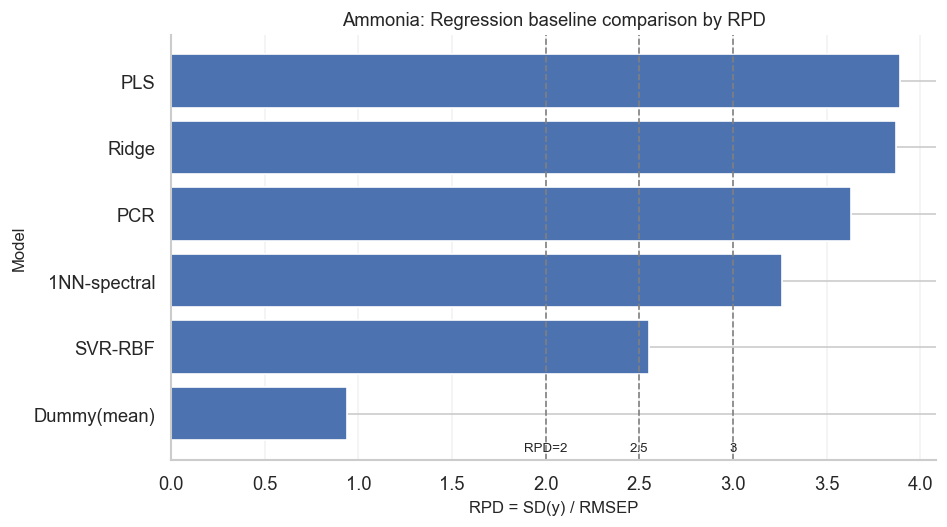

Saved: baseline_outputs\ammonia_baseline_rpd_bar.png
Saved: baseline_outputs\ammonia_baseline_rpd_bar.pdf


In [ ]:
# ============================================================
# CELL 22
# ONE-CELL REGRESSION BASELINES + RPD ANALYSIS
# Purpose:
# Runs leakage-safe leave-one-concentration-out regression baselines:
#   Dummy(mean), 1NN, Ridge, PCR, PLS, SVR-RBF
#
# Reports:
#   RMSEP, MAE, R2, RPD = SD(y) / RMSEP
#
# Main output variables:
#   baseline_summary_df
#   baseline_predictions_df
#   baseline_outer_folds_df
#   baseline_selection_df
#
# This produces the paper's comparator-regressor table/figure (RPD
# bar chart). Each model gets its own inner-CV hyperparameter search
# (USE_INNER_SELECTION) nested inside the outer LOCO loop, mirroring
# the same leakage-safe structure as the main PLS pipeline in CELL 10.
# ============================================================

import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from IPython.display import display
except Exception:
    display = print


# ============================================================
# CONFIGURATION
# ============================================================

# Keep this True for paper-quality comparison.
# It selects hyperparameters inside the outer training fold only.
USE_INNER_SELECTION = True

# Preprocessing used inside each model pipeline.
# Options:
#   "savgol_smooth"
#   "savgol_deriv1"
#   "standard_only"
PREPROCESS_MODE = "savgol_smooth"

# Savitzky-Golay settings.
# Change these only if your final regression protocol used different values.
SAVGOL_WINDOW = 11
SAVGOL_POLYORDER = 2

# Physical concentration cannot be negative.
CLIP_NEGATIVE_PREDICTIONS = True

# Output folder.
OUTDIR = "baseline_outputs"
os.makedirs(OUTDIR, exist_ok=True)

# Optional manual override.
# If auto-detection fails, uncomment and set these three lines:
#
# BASELINE_X = X
# BASELINE_y = y
# BASELINE_groups = groups
#
# Usually groups should be concentration labels for LOCO:
# BASELINE_groups = BASELINE_y


# ============================================================
# DATA AUTO-DETECTION
# ============================================================

def _numeric_pixel_cols(df, prefix="Pixel_"):
    """Return df's Pixel_<i> columns sorted numerically by pixel index."""
    cols = [c for c in df.columns if str(c).startswith(prefix)]
    try:
        cols = sorted(cols, key=lambda x: int(str(x).split("_")[1]))
    except Exception:
        cols = sorted(cols)
    return cols


def _resolve_regression_data():
    """
    Tries to find X, y, groups in the current regression notebook.

    Priority:
    1. Manual override: BASELINE_X, BASELINE_y, BASELINE_groups
    2. df_avg with Pixel_* columns and Concentration
    3. df_master with Pixel_* columns and Concentration
    4. Existing X and y variables, groups if available, else groups=y
    """

    # Manual override
    if all(name in globals() for name in ["BASELINE_X", "BASELINE_y", "BASELINE_groups"]):
        X0 = np.asarray(globals()["BASELINE_X"], dtype=float)
        y0 = np.asarray(globals()["BASELINE_y"], dtype=float).ravel()
        g0 = np.asarray(globals()["BASELINE_groups"]).ravel()
        return X0, y0, g0, "manual override: BASELINE_X / BASELINE_y / BASELINE_groups"

    # Prefer averaged dataframe if available
    for df_name in ["df_avg", "df_master", "df"]:
        if df_name in globals():
            df0 = globals()[df_name]
            if isinstance(df0, pd.DataFrame) and "Concentration" in df0.columns:
                pix_cols = _numeric_pixel_cols(df0)
                if len(pix_cols) > 0:
                    X0 = df0[pix_cols].values.astype(float)
                    y0 = df0["Concentration"].values.astype(float)
                    g0 = y0.copy()
                    return X0, y0, g0, f"{df_name}: Pixel_* columns + Concentration"

    # Existing arrays
    x_candidates = [
        "X",
        "X_raw",
        "X_full",
        "X_spectra",
        "X_avg",
        "X_reg",
        "X_model",
        "X_selected"
    ]

    y_candidates = [
        "y",
        "y_raw",
        "y_full",
        "y_avg",
        "y_reg",
        "concentrations"
    ]

    X0 = None
    y0 = None
    x_name = None
    y_name = None

    for name in x_candidates:
        if name in globals():
            arr = np.asarray(globals()[name])
            if arr.ndim == 2:
                X0 = arr.astype(float)
                x_name = name
                break

    for name in y_candidates:
        if name in globals():
            arr = np.asarray(globals()[name]).ravel()
            if arr.ndim == 1:
                y0 = arr.astype(float)
                y_name = name
                break

    if X0 is not None and y0 is not None and len(X0) == len(y0):
        group_candidates = ["groups", "logo_groups", "groups_logo", "concentration_groups"]

        g0 = None
        g_name = None

        for name in group_candidates:
            if name in globals():
                arr = np.asarray(globals()[name]).ravel()
                if len(arr) == len(y0):
                    g0 = arr
                    g_name = name
                    break

        if g0 is None:
            g0 = y0.copy()
            g_name = "y used as groups"

        return X0, y0, g0, f"arrays: X={x_name}, y={y_name}, groups={g_name}"

    raise ValueError(
        "Could not auto-detect regression data.\n\n"
        "Fix by adding these lines just above this cell:\n"
        "BASELINE_X = <your raw/feature matrix>\n"
        "BASELINE_y = <your concentration array>\n"
        "BASELINE_groups = BASELINE_y\n"
    )


X_baseline_input, y_baseline_input, groups_baseline_input, data_source_msg = _resolve_regression_data()

gas_name_for_baselines = (
    globals().get("GAS_NAME", None)
    or globals().get("gas_name", None)
    or "Gas"
)

gas_name_for_baselines = str(gas_name_for_baselines)

print("=" * 80)
print("BASELINE/RPD DATA CHECK")
print("=" * 80)
print(f"Gas: {gas_name_for_baselines}")
print(f"Data source: {data_source_msg}")
print(f"X shape: {X_baseline_input.shape}")
print(f"y shape: {y_baseline_input.shape}")
print(f"groups shape: {groups_baseline_input.shape}")
print(f"Unique concentration groups: {len(np.unique(groups_baseline_input))}")
print(f"Concentrations: {np.sort(np.unique(y_baseline_input))}")

assert X_baseline_input.ndim == 2
assert len(X_baseline_input) == len(y_baseline_input) == len(groups_baseline_input)
assert len(np.unique(groups_baseline_input)) >= 2, "Need at least two concentration groups for LOCO."


# ============================================================
# TRANSFORMERS
# ============================================================

class SafeSavgolSmooth(BaseEstimator, TransformerMixin):
    """
    Savitzky-Golay transformer that safely adjusts window length
    if the feature dimension is smaller than expected.
    """

    def __init__(self, window_length=11, polyorder=2, deriv=0):
        self.window_length = window_length
        self.polyorder = polyorder
        self.deriv = deriv

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)

        n_features = X.shape[1]
        window = int(self.window_length)

        # Window must be odd and <= n_features.
        if window > n_features:
            window = n_features

        if window % 2 == 0:
            window -= 1

        # Need window greater than polyorder.
        if window <= self.polyorder + 1 or window < 5:
            return X

        return savgol_filter(
            X,
            window_length=window,
            polyorder=self.polyorder,
            deriv=self.deriv,
            axis=1
        )


class NearestConcentrationRegressor(BaseEstimator):
    """
    1-nearest-neighbor regressor in spectral feature space.
    Predicts the concentration of the closest training spectrum.
    This is a useful memorization-style baseline.
    """

    def fit(self, X, y):
        self.X_ = np.asarray(X, dtype=float)
        self.y_ = np.asarray(y, dtype=float).ravel()
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)

        # Squared Euclidean distances.
        # Works fine for small spectroscopy datasets.
        d = ((X[:, None, :] - self.X_[None, :, :]) ** 2).sum(axis=2)
        nearest_idx = np.argmin(d, axis=1)

        return self.y_[nearest_idx]


def make_preprocessing_steps():
    """Build the (name, transformer) steps list selected by PREPROCESS_MODE."""
    if PREPROCESS_MODE == "savgol_smooth":
        return [
            ("sg", SafeSavgolSmooth(SAVGOL_WINDOW, SAVGOL_POLYORDER, deriv=0)),
            ("sc", StandardScaler())
        ]

    if PREPROCESS_MODE == "savgol_deriv1":
        return [
            ("sg", SafeSavgolSmooth(SAVGOL_WINDOW, SAVGOL_POLYORDER, deriv=1)),
            ("sc", StandardScaler())
        ]

    if PREPROCESS_MODE == "standard_only":
        return [
            ("sc", StandardScaler())
        ]

    raise ValueError(f"Unknown PREPROCESS_MODE: {PREPROCESS_MODE}")


# ============================================================
# MODEL GRID
# ============================================================

def model_configs(model_name, X_train):
    """
    Candidate hyperparameters for inner selection.
    Kept moderate so this cell runs in normal notebook time.
    """

    n_train, n_features = X_train.shape
    max_linear_components = max(1, min(n_train - 1, n_features, 10))

    if model_name == "Dummy(mean)":
        return [{"strategy": "mean"}]

    if model_name == "1NN-spectral":
        return [{}]

    if model_name == "Ridge":
        return [
            {"alpha": a}
            for a in [0.01, 0.1, 1.0, 10.0, 100.0]
        ]

    if model_name == "PCR":
        n_comp_grid = [1, 2, 3, 5, 8, 10]
        n_comp_grid = sorted(set([c for c in n_comp_grid if c <= max_linear_components]))
        return [
            {"n_components": c, "alpha": a}
            for c in n_comp_grid
            for a in [0.1, 1.0, 10.0]
        ]

    if model_name == "PLS":
        n_comp_grid = [1, 2, 3, 4, 5, 6, 8, 10]
        n_comp_grid = sorted(set([c for c in n_comp_grid if c <= max_linear_components]))
        return [
            {"n_components": c}
            for c in n_comp_grid
        ]

    if model_name == "SVR-RBF":
        return [
            {"C": C, "epsilon": eps, "gamma": "scale"}
            for C in [1.0, 10.0, 100.0]
            for eps in [0.1, 1.0, 5.0]
        ]

    raise ValueError(f"Unknown model name: {model_name}")


def make_estimator(model_name, cfg):
    """Build the sklearn Pipeline for model_name with hyperparameters cfg."""
    pre = make_preprocessing_steps()

    if model_name == "Dummy(mean)":
        return Pipeline([
            ("reg", DummyRegressor(strategy=cfg.get("strategy", "mean")))
        ])

    if model_name == "1NN-spectral":
        return Pipeline(pre + [
            ("reg", NearestConcentrationRegressor())
        ])

    if model_name == "Ridge":
        return Pipeline(pre + [
            ("reg", Ridge(alpha=cfg["alpha"]))
        ])

    if model_name == "PCR":
        return Pipeline(pre + [
            ("pca", PCA(n_components=cfg["n_components"])),
            ("reg", Ridge(alpha=cfg["alpha"]))
        ])

    if model_name == "PLS":
        return Pipeline(pre + [
            ("reg", PLSRegression(n_components=cfg["n_components"], scale=False))
        ])

    if model_name == "SVR-RBF":
        return Pipeline(pre + [
            ("reg", SVR(
                kernel="rbf",
                C=cfg["C"],
                epsilon=cfg["epsilon"],
                gamma=cfg["gamma"]
            ))
        ])

    raise ValueError(f"Unknown model name: {model_name}")


def is_valid_config(model_name, cfg, X_train):
    """
    Avoid invalid PCA/PLS component counts inside small inner folds.
    """
    n_train, n_features = X_train.shape
    max_components = max(1, min(n_train - 1, n_features))

    if model_name == "PCR":
        return cfg["n_components"] <= max_components

    if model_name == "PLS":
        return cfg["n_components"] <= max_components

    return True


def params_to_string(cfg):
    """Render a hyperparameter dict as a short human-readable string."""
    if not cfg:
        return "-"
    return ", ".join([f"{k}={v}" for k, v in cfg.items()])


# ============================================================
# NESTED LOCO EVALUATION
# ============================================================

def evaluate_inner_config(model_name, cfg, X_train_outer, y_train_outer, groups_train_outer):
    """
    Inner leave-one-concentration-out score for one model config.
    Uses only the outer-training data.
    Selection metric = RMSEP, then MAE, then higher R2.
    """

    inner_logo = LeaveOneGroupOut()

    inner_true = []
    inner_pred = []

    for inner_tr, inner_val in inner_logo.split(
        X_train_outer,
        y_train_outer,
        groups=groups_train_outer
    ):
        # Leakage audit: held-out concentration must not appear in training.
        assert not (
            set(groups_train_outer[inner_val]) & set(groups_train_outer[inner_tr])
        ), "INNER LEAKAGE: concentration overlap."

        X_inner_train = X_train_outer[inner_tr]
        y_inner_train = y_train_outer[inner_tr]

        X_inner_val = X_train_outer[inner_val]
        y_inner_val = y_train_outer[inner_val]

        if not is_valid_config(model_name, cfg, X_inner_train):
            return None

        est = make_estimator(model_name, cfg)
        est.fit(X_inner_train, y_inner_train)

        pred = np.asarray(est.predict(X_inner_val)).ravel()

        if CLIP_NEGATIVE_PREDICTIONS:
            pred = np.clip(pred, 0, None)

        inner_true.extend(y_inner_val.tolist())
        inner_pred.extend(pred.tolist())

    inner_true = np.asarray(inner_true, dtype=float)
    inner_pred = np.asarray(inner_pred, dtype=float)

    rmse = float(np.sqrt(mean_squared_error(inner_true, inner_pred)))
    mae = float(mean_absolute_error(inner_true, inner_pred))
    r2 = float(r2_score(inner_true, inner_pred))

    return {
        "Inner_RMSEP": rmse,
        "Inner_MAE": mae,
        "Inner_R2": r2
    }


def run_one_model_nested_loco(model_name, X, y, groups):
    """
    Outer leave-one-concentration-out.
    If USE_INNER_SELECTION=True, hyperparameters are selected using inner LOCO
    only on outer-training data.
    """

    outer_logo = LeaveOneGroupOut()

    oof_pred = np.full(len(y), np.nan, dtype=float)

    outer_rows = []
    selection_rows = []

    for outer_fold, (tr, te) in enumerate(outer_logo.split(X, y, groups=groups), start=1):

        # Leakage audit
        assert not (
            set(groups[te]) & set(groups[tr])
        ), "OUTER LEAKAGE: concentration overlap."

        X_train = X[tr]
        y_train = y[tr]
        groups_train = groups[tr]

        X_test = X[te]
        y_test = y[te]
        heldout_group = groups[te][0]

        cfgs = model_configs(model_name, X_train)

        # ----------------------------------------------------
        # Inner model selection
        # ----------------------------------------------------
        scored_cfgs = []

        if USE_INNER_SELECTION and len(np.unique(groups_train)) >= 2:
            for cfg in cfgs:
                score = evaluate_inner_config(
                    model_name,
                    cfg,
                    X_train,
                    y_train,
                    groups_train
                )

                if score is None:
                    continue

                row = {
                    "Model": model_name,
                    "Outer_Fold": outer_fold,
                    "Heldout_Concentration": heldout_group,
                    "Params": params_to_string(cfg),
                    **score
                }

                scored_cfgs.append(row)

            if len(scored_cfgs) == 0:
                # Fallback to first valid config.
                best_cfg = cfgs[0]
                best_score = {
                    "Inner_RMSEP": np.nan,
                    "Inner_MAE": np.nan,
                    "Inner_R2": np.nan
                }
            else:
                scored_df = pd.DataFrame(scored_cfgs)

                scored_df = scored_df.sort_values(
                    by=["Inner_RMSEP", "Inner_MAE", "Inner_R2"],
                    ascending=[True, True, False]
                ).reset_index(drop=True)

                best_params_str = scored_df.iloc[0]["Params"]

                # Recover config matching best param string.
                best_cfg = None
                for cfg in cfgs:
                    if params_to_string(cfg) == best_params_str:
                        best_cfg = cfg
                        break

                best_score = {
                    "Inner_RMSEP": scored_df.iloc[0]["Inner_RMSEP"],
                    "Inner_MAE": scored_df.iloc[0]["Inner_MAE"],
                    "Inner_R2": scored_df.iloc[0]["Inner_R2"]
                }

                selection_rows.extend(scored_df.to_dict("records"))

        else:
            best_cfg = cfgs[0]
            best_score = {
                "Inner_RMSEP": np.nan,
                "Inner_MAE": np.nan,
                "Inner_R2": np.nan
            }

        # ----------------------------------------------------
        # Fit selected model on full outer training set
        # ----------------------------------------------------
        est = make_estimator(model_name, best_cfg)
        est.fit(X_train, y_train)

        pred = np.asarray(est.predict(X_test)).ravel()

        if CLIP_NEGATIVE_PREDICTIONS:
            pred = np.clip(pred, 0, None)

        oof_pred[te] = pred

        fold_rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
        fold_mae = float(mean_absolute_error(y_test, pred))

        # R2 is not meaningful for single-concentration fold where y is constant.
        outer_rows.append({
            "Model": model_name,
            "Outer_Fold": outer_fold,
            "Heldout_Concentration": heldout_group,
            "N_Test": len(te),
            "Selected_Params": params_to_string(best_cfg),
            "Best_Inner_RMSEP": best_score["Inner_RMSEP"],
            "Best_Inner_MAE": best_score["Inner_MAE"],
            "Best_Inner_R2": best_score["Inner_R2"],
            "Outer_Fold_RMSEP": fold_rmse,
            "Outer_Fold_MAE": fold_mae
        })

    return oof_pred, pd.DataFrame(outer_rows), pd.DataFrame(selection_rows)


def run_all_baselines_nested_loco(X, y, groups, gas_name):
    """
    Run every comparator model through run_one_model_nested_loco and
    assemble the RMSEP/MAE/R2/RPD summary table plus per-prediction,
    per-fold, and inner-selection detail tables.
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).ravel()
    groups = np.asarray(groups).ravel()

    model_names = [
        "Dummy(mean)",
        "1NN-spectral",
        "Ridge",
        "PCR",
        "PLS",
        "SVR-RBF"
    ]

    summary_rows = []
    all_pred_rows = []
    all_outer_rows = []
    all_selection_rows = []

    sd_y = float(np.std(y, ddof=1))

    start = time.time()

    for model_name in model_names:
        print("\n" + "-" * 80)
        print(f"Running model: {model_name}")
        print("-" * 80)

        pred, outer_df, selection_df = run_one_model_nested_loco(
            model_name,
            X,
            y,
            groups
        )

        rmsep = float(np.sqrt(mean_squared_error(y, pred)))
        mae = float(mean_absolute_error(y, pred))
        r2 = float(r2_score(y, pred))
        rpd = float(sd_y / rmsep) if rmsep > 0 else np.nan

        summary_rows.append({
            "Gas": gas_name,
            "Model": model_name,
            "RMSEP_ppm": rmsep,
            "MAE_ppm": mae,
            "R2": r2,
            "RPD": rpd
        })

        pred_df = pd.DataFrame({
            "Gas": gas_name,
            "Model": model_name,
            "Actual_ppm": y,
            "Predicted_ppm": pred,
            "Group_Concentration": groups,
            "Absolute_Error_ppm": np.abs(y - pred)
        })

        all_pred_rows.append(pred_df)
        all_outer_rows.append(outer_df)

        if selection_df is not None and len(selection_df) > 0:
            all_selection_rows.append(selection_df)

        print(
            f"{model_name}: "
            f"RMSEP={rmsep:.3f} ppm | "
            f"MAE={mae:.3f} ppm | "
            f"R2={r2:.3f} | "
            f"RPD={rpd:.2f}"
        )

    elapsed = time.time() - start

    summary_df = pd.DataFrame(summary_rows)
    summary_df = summary_df.sort_values("RMSEP_ppm").reset_index(drop=True)

    pred_all_df = pd.concat(all_pred_rows, ignore_index=True)
    outer_all_df = pd.concat(all_outer_rows, ignore_index=True)

    if len(all_selection_rows) > 0:
        selection_all_df = pd.concat(all_selection_rows, ignore_index=True)
    else:
        selection_all_df = pd.DataFrame()

    print("\n" + "=" * 80)
    print(f"BASELINE/RPD ANALYSIS COMPLETE: {gas_name}")
    print("=" * 80)
    print(f"Elapsed time: {elapsed / 60:.2f} minutes")
    print(f"RPD interpretation: <2 poor, 2–2.5 fair, 2.5–3 good, >3 excellent")

    return summary_df, pred_all_df, outer_all_df, selection_all_df


# ============================================================
# RUN ANALYSIS
# ============================================================

baseline_summary_df, baseline_predictions_df, baseline_outer_folds_df, baseline_selection_df = (
    run_all_baselines_nested_loco(
        X=X_baseline_input,
        y=y_baseline_input,
        groups=groups_baseline_input,
        gas_name=gas_name_for_baselines
    )
)

# Rounded display table
baseline_summary_display = baseline_summary_df.copy()
baseline_summary_display["RMSEP_ppm"] = baseline_summary_display["RMSEP_ppm"].round(3)
baseline_summary_display["MAE_ppm"] = baseline_summary_display["MAE_ppm"].round(3)
baseline_summary_display["R2"] = baseline_summary_display["R2"].round(3)
baseline_summary_display["RPD"] = baseline_summary_display["RPD"].round(2)

print("\n" + "=" * 80)
print("FINAL BASELINE SUMMARY TABLE")
print("=" * 80)
display(baseline_summary_display)

print("\nSelected parameter counts by model:")
if len(baseline_outer_folds_df) > 0:
    display(
        baseline_outer_folds_df
        .groupby(["Model", "Selected_Params"])
        .size()
        .reset_index(name="Selected_Count")
        .sort_values(["Model", "Selected_Count"], ascending=[True, False])
    )


# ============================================================
# SAVE OUTPUTS
# ============================================================

safe_gas = gas_name_for_baselines.lower().replace(" ", "_")

summary_path = os.path.join(OUTDIR, f"{safe_gas}_baseline_summary_rpd.csv")
pred_path = os.path.join(OUTDIR, f"{safe_gas}_baseline_predictions.csv")
outer_path = os.path.join(OUTDIR, f"{safe_gas}_baseline_outer_folds.csv")
selection_path = os.path.join(OUTDIR, f"{safe_gas}_baseline_inner_selection.csv")

baseline_summary_display.to_csv(summary_path, index=False)
baseline_predictions_df.to_csv(pred_path, index=False)
baseline_outer_folds_df.to_csv(outer_path, index=False)
baseline_selection_df.to_csv(selection_path, index=False)

print("\nSaved:")
print(summary_path)
print(pred_path)
print(outer_path)
print(selection_path)


# ============================================================
# SIMPLE PUBLICATION-STYLE BAR CHART: RPD BY MODEL
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4.5))

plot_df = baseline_summary_display.sort_values("RPD", ascending=True)

ax.barh(
    plot_df["Model"],
    plot_df["RPD"]
)

ax.axvline(2.0, linestyle="--", linewidth=1, color="gray")
ax.axvline(2.5, linestyle="--", linewidth=1, color="gray")
ax.axvline(3.0, linestyle="--", linewidth=1, color="gray")

ax.text(2.0, -0.6, "RPD=2", ha="center", va="bottom", fontsize=8)
ax.text(2.5, -0.6, "2.5", ha="center", va="bottom", fontsize=8)
ax.text(3.0, -0.6, "3", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("RPD = SD(y) / RMSEP")
ax.set_ylabel("Model")
ax.set_title(f"{gas_name_for_baselines}: Regression baseline comparison by RPD")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

fig_path_png = os.path.join(OUTDIR, f"{safe_gas}_baseline_rpd_bar.png")
fig_path_pdf = os.path.join(OUTDIR, f"{safe_gas}_baseline_rpd_bar.pdf")

fig.savefig(fig_path_png, dpi=300, bbox_inches="tight")
fig.savefig(fig_path_pdf, dpi=300, bbox_inches="tight")

print(f"Saved: {fig_path_png}")
print(f"Saved: {fig_path_pdf}")